## Підготовка середовища

Встановлення залежностей. Запустити один раз при першому запуску.

In [238]:
# Встановлення залежностей (запускати один раз)
%pip install torch numpy pandas matplotlib yfinance pyyaml ipykernel pywavelets einops scipy --quiet


Note: you may need to restart the kernel to use updated packages.


# Прогнозування фінансових часових рядів за допомогою Transformer-архітектур

**Мета роботи** — порівняти ефективність LSTM, Vanilla Transformer, Informer, Autoformer,
FedFormer, iTransformer та Frequency-enhanced iTransformer на задачі мульти-горизонтного
прогнозування log-returns індексу S&P 500.

**Оцінка** проводиться за методологією Walk-Forward Cross-Validation: модель перевіряється
на всіх ринкових режимах з 2015 по 2025, а не лише на одному фіксованому відрізку.


## 0. Налаштування середовища

In [239]:
import os

import numpy as np
import pandas as pd
import torch

DEVICE   = ("mps" if torch.backends.mps.is_available()
            else "cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "data/raw"
RESULTS  = "results/clean"

print(f"Device: {DEVICE}")

Device: mps


---
## 1. Завантаження даних

### Набір даних

Для навчання та оцінки використовуються щоденні OHLCV-дані (Open, High, Low, Close, Volume)
для **29 фінансових інструментів**, завантажених з Yahoo Finance через бібліотеку `yfinance`.

| Клас | Інструменти |
|---|---|
| Фондові індекси | S&P 500 *(ціль)*, NASDAQ, Dow Jones, Russell 2000, FTSE 100, DAX, Nikkei 225, Shanghai |
| Сектори | XLK (Tech), XLF (Financials), XLE (Energy), XLV (Health) |
| Commodities | Gold, Silver, Crude Oil WTI, Natural Gas, Copper |
| Облігації / ставки | US 10Y, US 13W Treasury, TLT 20Y Bond, TIPS ETF, HYG High Yield |
| Валюти | USD Index, EUR-USD, JPY-USD, GBP-USD |
| Крипто | BTC-USD, ETH-USD |
| Волатильність | VIX |

**Діапазон:** 2000-01-03 → сьогодні (обмежено датами початку кожного тікера).
Відсутні дані (тікер ще не існував) заповнюються нулями.

### Завантаження
Читання метаданних про тікери з `tickers.csv` та завантаження історичних даних через `yfinance`:


In [240]:
import yfinance as yf

os.makedirs(DATA_DIR, exist_ok=True)
tickers_df = pd.read_csv("tickers.csv")

for _, row in tickers_df.iterrows():
    out_path = os.path.join(DATA_DIR, f"{row['filename']}.csv")
    if os.path.exists(out_path):
        print(f"  [SKIP] {row['name']} — вже завантажено")
        continue
    try:
        data = yf.download(row["yfinance_id"], start="2000-01-01", progress=False, auto_adjust=True)
        if data.empty:
            print(f"  [SKIP] {row['name']} — немає даних")
            continue
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        data = data[["Open", "High", "Low", "Close", "Volume"]]
        data.index.name = "Date"
        data.to_csv(out_path)
        print(f"  [OK]   {row['name']} ({row['yfinance_id']}) — {len(data)} рядків")
    except Exception as e:
        print(f"  [ERR]  {row['name']} — {e}")

display(tickers_df)

  [SKIP] S&P500 — вже завантажено
  [SKIP] NASDAQ Composite — вже завантажено
  [SKIP] Dow Jones — вже завантажено
  [SKIP] Russell 2000 — вже завантажено
  [SKIP] VIX — вже завантажено
  [SKIP] US Dollar Index — вже завантажено
  [SKIP] Gold Futures — вже завантажено
  [SKIP] Crude Oil WTI — вже завантажено
  [SKIP] BTC-USD — вже завантажено
  [SKIP] XLK Technology — вже завантажено
  [SKIP] XLF Financials — вже завантажено
  [SKIP] XLE Energy — вже завантажено
  [SKIP] XLV Health Care — вже завантажено
  [SKIP] US 10Y Treasury — вже завантажено
  [SKIP] US 13W Treasury — вже завантажено
  [SKIP] TLT 20Y Bond — вже завантажено
  [SKIP] Silver Futures — вже завантажено
  [SKIP] Natural Gas — вже завантажено
  [SKIP] Copper Futures — вже завантажено
  [SKIP] EUR-USD — вже завантажено
  [SKIP] JPY-USD — вже завантажено
  [SKIP] GBP-USD — вже завантажено
  [SKIP] ETH-USD — вже завантажено
  [SKIP] FTSE 100 — вже завантажено
  [SKIP] DAX — вже завантажено
  [SKIP] Nikkei 225 — вже завантаж

,name,yfinance_id,filename,start_date,has_volume,is_target
0,S&P500,^GSPC,SandP500,1950-01-03,1,1
1,NASDAQ Composite,^IXIC,NASDAQ_Composite,1971-02-05,1,0
2,Dow Jones,^DJI,Dow_Jones,1992-01-02,1,0
3,Russell 2000,^RUT,Russell_2000,1987-09-10,1,0
4,VIX,^VIX,VIX,1990-01-02,0,0
5,US Dollar Index,DX-Y.NYB,US_Dollar_Index,1971-01-04,1,0
6,Gold Futures,GC=F,Gold_Futures,2000-08-30,1,0
7,Crude Oil WTI,CL=F,Crude_Oil_WTI,2000-08-23,1,0
8,BTC-USD,BTC-USD,BTC-USD,2014-09-17,1,0
9,XLK Technology,XLK,XLK_Technology,1998-12-22,1,0


### Читання даних в пам'ять

Читаємо завантажені CSV-файли з `data/raw/` і будуємо MultiIndex DataFrame `df` з колонками `(ticker, feature)`. Тікери без реального volume (індекси, валюти) — обнуляємо цю колонку. Рядки, де S&P 500 Close відсутній, відкидаємо; решту пропусків заповнюємо нулем.

In [241]:
FEATURES = ["Open", "High", "Low", "Close", "Volume"]

has_volume_map = dict(zip(
    tickers_df["filename"].astype(str),
    tickers_df["has_volume"].fillna(0).astype(int)
))

frames = {}
for fname in sorted(os.listdir(DATA_DIR)):
    if not fname.endswith(".csv"):
        continue
    ticker = fname.replace(".csv", "")
    ticker_df = pd.read_csv(os.path.join(DATA_DIR, fname), index_col="Date", parse_dates=True)
    ticker_df = ticker_df.sort_index()
    ticker_df = ticker_df[[c for c in FEATURES if c in ticker_df.columns]]
    if has_volume_map.get(ticker, 1) == 0 and "Volume" in ticker_df.columns:
        ticker_df["Volume"] = 0.0
    frames[ticker] = ticker_df

df = pd.concat(frames, axis=1)
df.columns.names = ["ticker", "feature"]
df = df[df[("SandP500", "Close")].notna()]
df = df.fillna(0.0)

print(f"DataFrame: {df.shape[0]} торгових днів, {df.columns.get_level_values('ticker').nunique()} тікерів")
print(f"Діапазон: {df.index[0].date()} → {df.index[-1].date()}")

DataFrame: 6618 торгових днів, 29 тікерів
Діапазон: 2000-01-03 → 2026-04-27


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/459028573.py:20: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat(frames, axis=1)


### Огляд даних

Графік ціни закриття S&P 500 (2000–2025) та горизонтальний таймлайн — коли починається історія для кожного з 29 тікерів.

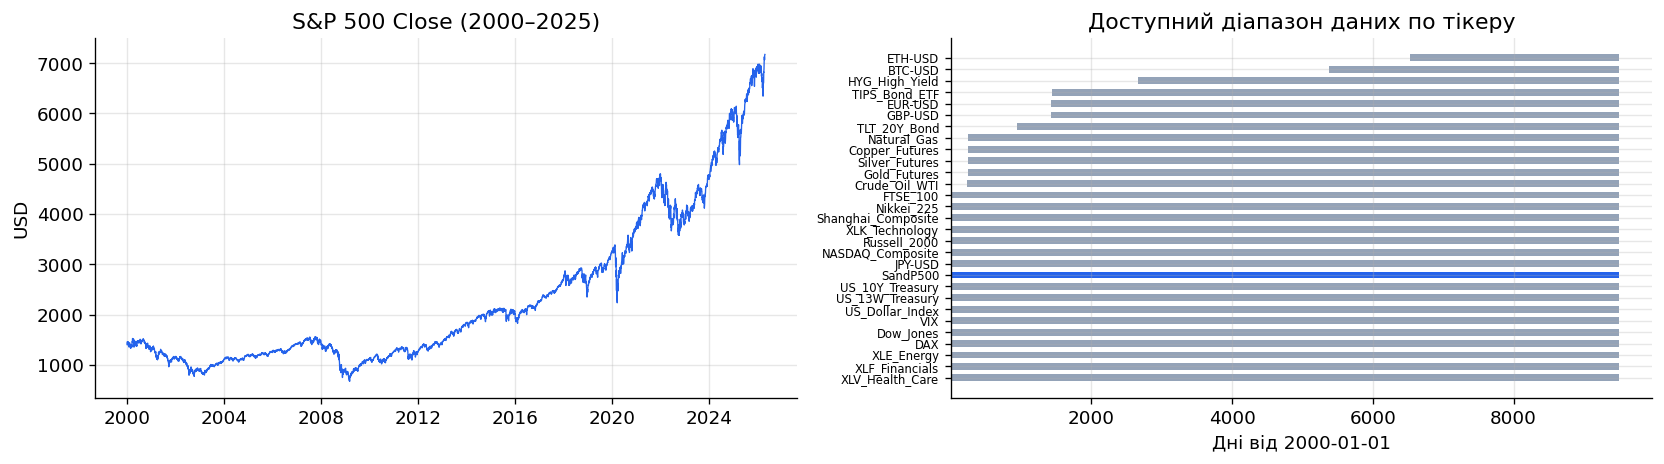

In [242]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

# Огляд цін закриття S&P500
sp = df[("SandP500", "Close")]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(sp.index, sp.values, lw=0.8, color="#2563eb")
axes[0].set_title("S&P 500 Close (2000–2025)")
axes[0].set_ylabel("USD")

# Тікер-таймлайн: коли починаються дані
starts = {}
for ticker in df.columns.get_level_values("ticker").unique():
    s = df[(ticker, "Close")].replace(0, np.nan).first_valid_index()
    if s: starts[ticker] = s

start_df = pd.Series(starts).sort_values()
colors = ["#2563eb" if t == "SandP500" else "#94a3b8" for t in start_df.index]
axes[1].barh(range(len(start_df)), [(pd.Timestamp("2026-01-01") - d).days for d in start_df],
             left=[(d - pd.Timestamp("2000-01-01")).days for d in start_df], color=colors, height=0.6)
axes[1].set_yticks(range(len(start_df)))
axes[1].set_yticklabels(start_df.index, fontsize=7)
axes[1].set_title("Доступний діапазон даних по тікеру")
axes[1].set_xlabel("Дні від 2000-01-01")
plt.tight_layout()
plt.show()


---
## 2. Опис задачі

### Цільова змінна

Модель прогнозує **log-returns** індексу S&P 500 на трьох горизонтах одночасно
(multi-task regression):

$$y_h = \ln\!\left(\frac{P_{t+h}}{P_t}\right), \quad h \in \{1,\, 3,\, 10\}$$

| Горизонт | Торгові дні | Приблизно |
|---|---|---|
| $t+1$ | 1 день | завтра |
| $t+3$ | 3 дні | тиждень |
| $t+10$ | 10 днів | 2 тижні |

Log-return, а не абсолютна ціна, бо: (1) стаціонарний, (2) не залежить від масштабу
ціни (100$ vs 5000$), (3) симетричний — однаковий +10% не компенсується наступним -10%.

### Функція втрат

$$\mathcal{L} = \frac{1}{3} \sum_{h \in \{1,3,10\}} \text{MSE}(\hat{y}_h,\, y_h)$$

Multi-task навчання стабілізує градієнти: модель не може "переспеціалізуватися" на одному горизонті.

### Метрики оцінки

| Метрика | Формула | Інтерпретація |
|---|---|---|
| MSE | $\frac{1}{N}\sum(\hat{y}-y)^2$ | чутлива до великих помилок |
| MAE | $\frac{1}{N}\sum\lvert\hat{y}-y\rvert$ | середня абсолютна помилка в log-return |
| DirAcc | $\frac{1}{N}\sum\mathbf{1}[\text{sign}(\hat{y}) = \text{sign}(y)]$ | % правильних напрямків руху |

DirAcc 50% — не краще за монету. Мета: DirAcc > 55% на t+1.

In [243]:
import torch.nn.functional as F

HORIZONS = [5, 15]  # горизонти прогнозування (торгові дні)

close = df[("SandP500", "Close")]
print(f"{'Горизонт':>10}  {'Середнє':>10}  {'Std':>8}  {'Min':>8}  {'Max':>8}  {'|y|<0.001':>10}")
for h in HORIZONS:
    lr = np.log(close / close.shift(h)).dropna()
    tiny = (lr.abs() < 0.001).mean()
    print(f"  t+{h:<7}  {lr.mean():>10.5f}  {lr.std():>8.5f}  {lr.min():>8.5f}  {lr.max():>8.5f}  {tiny:>9.1%}")


  Горизонт     Середнє       Std       Min       Max   |y|<0.001
  t+5           0.00122   0.02479  -0.20261   0.17489       4.3%
  t+15          0.00359   0.04124  -0.33343   0.24062       2.0%


### Розподіл цільових змінних

Гістограми log-returns S&P 500 для трьох горизонтів прогнозування. Розподіл симетричний навколо нуля — підтверджує доцільність log-return як цільової змінної.

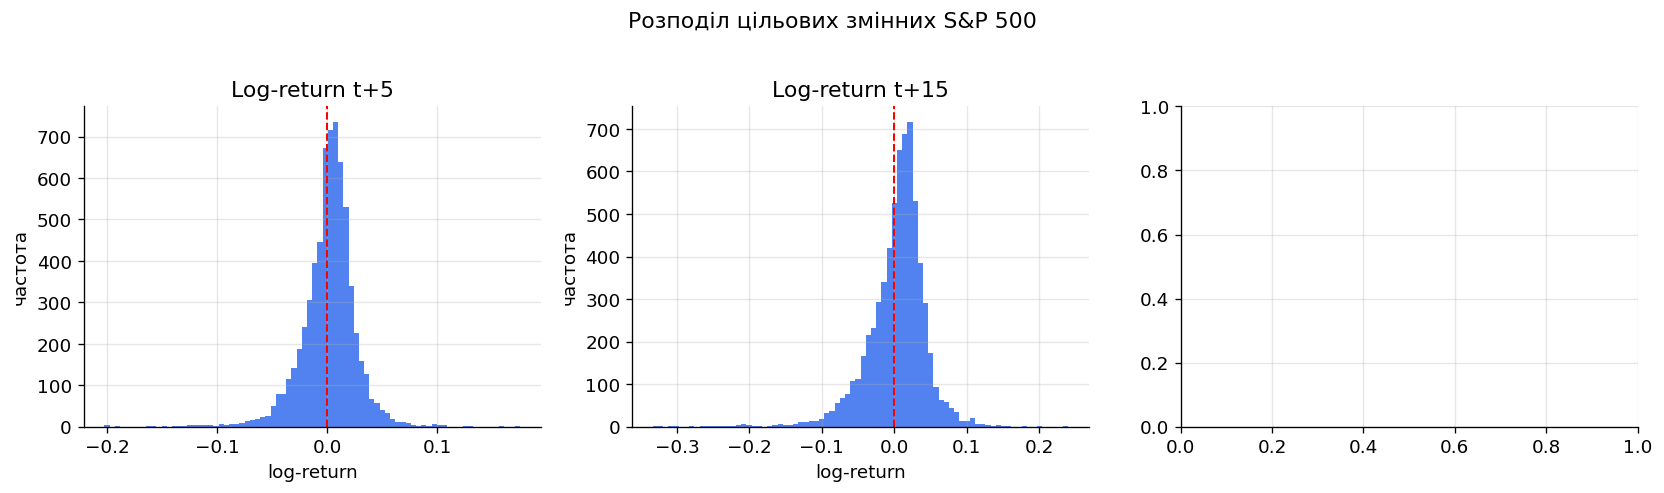

In [244]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, h in zip(axes, HORIZONS):
    lr = np.log(close / close.shift(h)).dropna()
    ax.hist(lr, bins=80, color="#2563eb", alpha=0.8, edgecolor="none")
    ax.axvline(0, color="red", lw=1.2, ls="--")
    ax.set_title(f"Log-return t+{h}")
    ax.set_xlabel("log-return")
    ax.set_ylabel("частота")
plt.suptitle("Розподіл цільових змінних S&P 500", y=1.02)
plt.tight_layout()
plt.show()


### Функція метрик

Визначаємо `compute_metrics`: для кожного горизонту рахує MSE, MAE і DirAcc. Перевіряємо коректність на нульовому предикторі — очікуємо DirAcc ≈ 50%.

In [245]:
# Метрики: демонстрація на синтетичних даних
def compute_metrics(pred: torch.Tensor, target: torch.Tensor, horizons=HORIZONS) -> dict:
    metrics = {}
    for i, h in enumerate(horizons):
        p, t = pred[:, i], target[:, i]
        metrics[f"MSE_t{h}"]    = F.mse_loss(p, t).item()
        metrics[f"MAE_t{h}"]    = F.l1_loss(p, t).item()
        metrics[f"DirAcc_t{h}"] = ((p > 0) == (t > 0)).float().mean().item()
    return metrics

# Базова перевірка: нульовий предиктор
N = 500
targets_demo = torch.randn(N, 3) * 0.01
zero_pred    = torch.zeros(N, 3)
print("Метрики нульового предиктора:")
for k, v in compute_metrics(zero_pred, targets_demo).items():
    print(f"  {k:<15} {v:.6f}")


Метрики нульового предиктора:
  MSE_t5          0.000092
  MAE_t5          0.007671
  DirAcc_t5       0.510000
  MSE_t15         0.000098
  MAE_t15         0.008032
  DirAcc_t15      0.504000


---
## 3. Підготовка даних

### Нормалізація (z-score)

Кожна фіча нормалізується: $\tilde{x} = (x - \mu_{\text{train}}) / \sigma_{\text{train}}$.
`mean` і `std` фітуються **тільки на тренувальному вікні** і фіксуються для val/test.

**Два edge-cases, що обробляються явно:**

1. **Константні фічі** — тікери що не існували в тренувальному вікні (ETH до 2017) мають
   $\sigma = 0$. При заміні 0→1 нормалізована ціна в val/test = сира ціна (~\$800).
   Рішення: `const_mask` — зберігаємо такі колонки і обнуляємо їх у val/test.

2. **Out-of-distribution екстремуми** — BTC Volume у 2017 = **1058σ** відносно
   тренувального розподілу. Рішення: `clip(±10σ)` після нормалізації.


In [246]:
from torch.utils.data import Dataset

TRAIN_END = "2020-12-31"
VAL_END   = "2022-12-31"


class MarketDataset(Dataset):
    def __init__(self, df, target_ticker="SandP500", lookback=60, horizons=None,
                 split="train", mean=None, std=None, date_from=None, date_to=None,
                 const_mask=None):
        horizons = horizons or [1, 3, 10]
        self.lookback = lookback
        self.horizons = horizons
        self.max_h = max(horizons)

        if date_from is not None or date_to is not None:
            mask = pd.Series(True, index=df.index)
            if date_from:
                mask &= df.index >= date_from
            if date_to:
                mask &= df.index <= date_to
            subset = df[mask]
        elif split == "train":
            subset = df[df.index <= TRAIN_END]
        elif split == "val":
            subset = df[(df.index > TRAIN_END) & (df.index <= VAL_END)]
        else:
            subset = df[df.index > VAL_END]

        # Convert prices/volume to log-returns: log(x_t) - log(x_{t-1}).
        # Save target_close prices BEFORE conversion (target Y still uses raw prices).
        # Volume can be 0 (holidays etc.) — replace with NaN, then ffill/bfill before log.
        target_close_prices = subset[(target_ticker, "Close")].astype(np.float32).values
        clean   = subset.replace(0, np.nan).ffill().bfill()
        returns = np.log(clean).diff().iloc[1:]
        returns = returns.replace([np.inf, -np.inf], 0.0).fillna(0.0)
        subset  = returns
        target_close_prices = target_close_prices[1:]   # align with returns rows

        if mean is None:
            raw_std    = subset.std()
            const_mask = raw_std[raw_std == 0].index
            mean       = subset.mean()
            std        = raw_std.replace(0, 1)
        self.mean       = mean
        self.std        = std
        self.const_mask = const_mask if const_mask is not None else pd.Index([])

        norm = (subset - mean) / std
        if len(self.const_mask) > 0:
            norm[self.const_mask] = 0.0
        norm = norm.fillna(0.0).clip(-10.0, 10.0)

        self.data         = norm.values.astype(np.float32)
        self.dates        = subset.index
        self.target_close = target_close_prices
        self.valid_idx    = np.arange(lookback, len(self.data) - self.max_h)

    def __len__(self):
        return len(self.valid_idx)

    def __getitem__(self, idx):
        i  = self.valid_idx[idx]
        x  = self.data[i - self.lookback : i]
        p0 = self.target_close[i]
        y  = np.array([np.log((self.target_close[i + h] / p0) + 1e-8) for h in self.horizons], dtype=np.float32)
        return torch.from_numpy(x), torch.from_numpy(y)


LOOKBACK = 60

train_ds = MarketDataset(df, target_ticker="SandP500", lookback=LOOKBACK, horizons=HORIZONS, split="train")
val_ds   = MarketDataset(df, target_ticker="SandP500", lookback=LOOKBACK, horizons=HORIZONS, split="val",
                         mean=train_ds.mean, std=train_ds.std, const_mask=train_ds.const_mask)

x0, y0 = train_ds[0]
print(f"Вхідний тензор x: {tuple(x0.shape)}  (lookback={LOOKBACK}, n_features={x0.shape[-1]})")
print(f"  n_tickers={df.columns.get_level_values('ticker').nunique()}, "
      f"n_ohlcv=5  →  {df.columns.get_level_values('ticker').nunique()}×5={x0.shape[-1]}")
print(f"Цільовий вектор y: {tuple(y0.shape)}  ({HORIZONS})")
print(f"\nСтатистика x (train): mean≈{train_ds.data.mean():.3f}  std≈{train_ds.data.std():.3f}"
      f"  max|x|≈{abs(train_ds.data).max():.2f}")
print(f"Константних фіч у train: {len(train_ds.const_mask)}")
print(f"  Приклади: {list(train_ds.const_mask[:5])}")

Вхідний тензор x: (60, 145)  (lookback=60, n_features=145)
  n_tickers=29, n_ohlcv=5  →  29×5=145
Цільовий вектор y: (2,)  ([5, 15])

Статистика x (train): mean≈0.000  std≈0.954  max|x|≈10.00
Константних фіч у train: 4
  Приклади: [('EUR-USD', 'Volume'), ('GBP-USD', 'Volume'), ('JPY-USD', 'Volume'), ('VIX', 'Volume')]


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


### Trainer — цикл навчання

Визначаємо `EarlyStopping` і `Trainer`: стандартний AdamW + CosineAnnealingLR, рання зупинка з відновленням найкращих ваг. Використовується для всіх моделей.

In [247]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR


class EarlyStopping:
    def __init__(self, patience=10):
        self.patience   = patience
        self.counter    = 0
        self.best       = float("inf")
        self.stop       = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best - 1e-6:
            self.best       = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        return self.stop


def _clip_grad_norm_safe(parameters, max_norm):
    """
    Як nn.utils.clip_grad_norm_, але обробляє комплексні градієнти (потрібно для FEDformer).
    PyTorch ще не підтримує norm ops для complex tensors напряму.
    """
    params = [p for p in parameters if p.grad is not None]
    if not params:
        return torch.tensor(0.0)
    device = params[0].grad.device
    total_sq = torch.zeros((), device=device)
    for p in params:
        g = p.grad
        g_real = torch.view_as_real(g) if g.is_complex() else g
        total_sq = total_sq + g_real.detach().pow(2).sum()
    total_norm = total_sq.sqrt()
    clip_coef = max_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        for p in params:
            p.grad.detach().mul_(clip_coef.to(p.grad.dtype) if p.grad.is_complex() else clip_coef)
    return total_norm


class Trainer:
    def __init__(self, model, train_loader, val_loader, lr=1e-3, max_epochs=50,
                 patience=10, horizons=None, device="cpu", loss_kind="mse"):
        self.model        = model.to(device)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.device       = device
        self.horizons     = horizons or [1, 3, 10]
        self.max_epochs   = max_epochs
        assert loss_kind in ("mse", "bce"), f"unknown loss_kind: {loss_kind}"
        self.loss_kind    = loss_kind
        self.criterion    = nn.MSELoss() if loss_kind == "mse" else nn.BCEWithLogitsLoss()
        self.optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
        self.scheduler    = CosineAnnealingLR(self.optimizer, T_max=max_epochs)
        self.early_stop   = EarlyStopping(patience)
        self.history      = {"train_loss": [], "val_loss": []}

    def _epoch(self, loader, train):
        self.model.train(train)
        total = 0.0
        with torch.set_grad_enabled(train):
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)
                pred = self.model(x)
                target = (y > 0).float() if self.loss_kind == "bce" else y
                loss = self.criterion(pred, target)
                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    _clip_grad_norm_safe(self.model.parameters(), 1.0)
                    self.optimizer.step()
                total += loss.item() * len(x)
        return total / len(loader.dataset)

    def fit(self):
        for epoch in range(1, self.max_epochs + 1):
            tr = self._epoch(self.train_loader, train=True)
            vl = self._epoch(self.val_loader,   train=False)
            self.scheduler.step()
            self.history["train_loss"].append(tr)
            self.history["val_loss"].append(vl)
            if self.early_stop(vl, self.model):
                print(f"  epoch {epoch:3d} | train {tr:.5f} | val {vl:.5f}  → early stop")
                break
        if self.early_stop.best_state:
            self.model.load_state_dict(
                {k: v.to(self.device) for k, v in self.early_stop.best_state.items()}
            )
        return self.history

    @torch.no_grad()
    def evaluate(self, loader):
        self.model.eval()
        preds, targets = [], []
        for x, y in loader:
            preds.append(self.model(x.to(self.device)).cpu())
            targets.append(y)
        return compute_metrics(torch.cat(preds), torch.cat(targets), self.horizons)

---
## 4. Загальна методологія

Усі моделі (від baseline до Informer) проганяються через **єдиний пайплайн**, що описаний нижче.
Замість дублювання тренувальних циклів і циклів пошуку гіперпараметрів — спершу визначаємо
кілька допоміжних функцій, а потім кожна модель зводиться до 5–10 рядків коду.

### Walk-Forward Cross-Validation

Звичайний фіксований split тестує модель лише на **одному** ринковому режимі.
Walk-Forward перевіряє її на кожному з них:

```
Ітерація 1:  Train [2000–2014]  →  Test [2015]
Ітерація 2:  Train [2000–2015]  →  Test [2016]
...
Ітерація 11: Train [2000–2024]  →  Test [2025]
```

**Expanding window**: тренувальний набір зростає на 1 рік за ітерацію.
Останні `VAL_WINDOW = 252` торгових днів кожного train-вікна резервуються для
ранньої зупинки (val); тест — повний наступний рік.

Тестові вікна покривають: відновлення (2015–19), COVID-обвал (2020), ведмежий ринок (2022),
ринок 2023–25 — тобто фундаментально різні режими.

Фінальна метрика — **mean ± std** по всіх 11 тестових вікнах.
Це значно надійніша оцінка, ніж результат на одному фіксованому test-вікні.

In [248]:
def generate_folds(df, train_start="2000-01-01", first_test_year=2015, last_test_year=2025):
    folds = []
    for test_year in range(first_test_year, last_test_year + 1):
        test_from   = f"{test_year}-01-01"
        test_to     = f"{test_year}-12-31"
        train_dates = df.index[df.index < test_from]
        if len(train_dates) == 0:
            continue
        folds.append((train_start, str(train_dates[-1].date()), test_from, test_to))
    return folds


folds = generate_folds(df)
print(f"Кількість фолдів: {len(folds)}\n")
print(f"{'Фолд':>5}  {'Train від':>12}  {'Train до':>12}  {'Test від':>12}  {'Test до':>12}")
for i, (tf, tt, ef, et) in enumerate(folds):
    print(f"  {i+1:>3}    {tf}    {tt}    {ef}    {et}")

Кількість фолдів: 11

 Фолд     Train від      Train до      Test від       Test до
    1    2000-01-01    2014-12-31    2015-01-01    2015-12-31
    2    2000-01-01    2015-12-31    2016-01-01    2016-12-31
    3    2000-01-01    2016-12-30    2017-01-01    2017-12-31
    4    2000-01-01    2017-12-29    2018-01-01    2018-12-31
    5    2000-01-01    2018-12-31    2019-01-01    2019-12-31
    6    2000-01-01    2019-12-31    2020-01-01    2020-12-31
    7    2000-01-01    2020-12-31    2021-01-01    2021-12-31
    8    2000-01-01    2021-12-31    2022-01-01    2022-12-31
    9    2000-01-01    2022-12-30    2023-01-01    2023-12-31
   10    2000-01-01    2023-12-29    2024-01-01    2024-12-31
   11    2000-01-01    2024-12-31    2025-01-01    2025-12-31


### Пошук гіперпараметрів (grid search)

Для кожної архітектури — окрема сітка значень. Стратегія:

1. **Фіксований split** train (2000–2020) / val (2021–2022) для всіх trial-ів
   (швидко, не потрібно повторювати walk-forward для кожного конфігу).
2. `max_epochs = 30`, рання зупинка з `patience = 7`.
3. Для кожного валідного trial-у записуємо `min(val_loss)` і номер епохи.
4. Сортуємо за `val_loss` ↑, найкращий конфіг → walk-forward.

Філософія: HP search дає **проксі** на якість, walk-forward — реальну метрику.
Невелика втрата якості HP search через фіксований split компенсується дешевизною —
повний walk-forward на кожному з 50–100 trial-ів зайняв би години.

### Дві версії входу: multivariate vs univariate

Кожну архітектуру оцінюємо у **двох варіантах**:

| Варіант | Дані | $N_F$ | Сенс |
|---|---|---|---|
| **Повна** | усі 29 тікерів × OHLCV | 145 | чи додає крос-asset інформація користь? |
| **Simple** | тільки S\&P 500 × OHLCV | 5 | базова продуктивність архітектури на даних цілі |

Якщо **simple** не сильно гірша за повну — це ознака того, що додаткові тікери або
шумні, або модель не вміє їх ефективно використовувати. Це окрема діагностика.

In [249]:
TARGET_TICKER = "SandP500"

# Тільки S&P 500 (для simple-варіантів моделей)
df_sp = df.loc[:, df.columns.get_level_values("ticker") == TARGET_TICKER].copy()
print(f"df:    {df.shape}    ({df.columns.get_level_values('ticker').nunique()} тікерів)")
print(f"df_sp: {df_sp.shape}    (1 тікер, OHLCV)")

df:    (6618, 145)    (29 тікерів)
df_sp: (6618, 5)    (1 тікер, OHLCV)


### Допоміжні функції — пайплайн в одному місці

Чотири функції, що використовуються для **всіх** моделей:

| Функція | Що робить |
|---|---|
| `aggregate_metrics(folds)` | mean/std по всіх фолдах |
| `run_hp_search(...)` | grid search на фіксованому split, повертає відсортований DataFrame |
| `run_walk_forward(...)` | 11-фолдовий walk-forward, зберігає JSON, повертає (folds, agg) |
| `plot_walk_forward(...)` | порівняльні графіки для довільного набору моделей |
| `summary_table(...)` | агрегована таблиця по всіх моделях |

Інтерфейс уніфіковано через **model factory** — функцію `factory(n_features, **params) → nn.Module`.
Це дає змогу для кожної моделі задати лише сітку гіперпараметрів і спосіб конструювання,
а вся ML-механіка (split, dataloader, навчання, рання зупинка, оцінка, агрегація) — одна для всіх.

In [250]:
import os
import json
import itertools
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# ── 1. Aggregation ───────────────────────────────────────────────────────────
def aggregate_metrics(fold_results):
    """mean/std по всіх фолдах для кожної метрики."""
    if not fold_results:
        return {}
    agg = {}
    for k in [x for x in fold_results[0] if x not in ("test_from", "test_to")]:
        vals = [m[k] for m in fold_results]
        agg[f"{k}_mean"] = float(np.mean(vals))
        agg[f"{k}_std"]  = float(np.std(vals))
    return agg


# ── 2. HP search ─────────────────────────────────────────────────────────────
def run_hp_search(model_factory, search_grid, df_data, save_dir,
                  filter_fn=None, hp_epochs=30, hp_patience=7, batch_size=64,
                  lookback=None, horizons=None, device=None, loss_kind="mse"):
    """
    Grid search по `search_grid`. Train = `MarketDataset(split="train")`; held-out = всі дані після `TRAIN_END` (val ∪ test).
    `model_factory(n_features, **model_params) → nn.Module`.
    `lr` у grid → передається у Trainer (а не у фабрику).
    Зберігає {save_dir}/hparam_search.csv, повертає DataFrame, відсортований за val_loss.
    """
    lookback = lookback or LOOKBACK
    horizons = horizons or HORIZONS
    device   = device   or DEVICE

    keys   = list(search_grid.keys())
    trials = [dict(zip(keys, v)) for v in itertools.product(*search_grid.values())]
    if filter_fn is not None:
        trials = [t for t in trials if filter_fn(t)]
    print(f"Total trials: {len(trials)}")

    train_ds = MarketDataset(df_data, lookback=lookback, horizons=horizons, split="train")
    # Held-out = val ∪ test (everything after TRAIN_END) — larger, more stable HP signal.
    val_from = str((pd.to_datetime(TRAIN_END) + pd.Timedelta(days=1)).date())
    val_ds   = MarketDataset(df_data, lookback=lookback, horizons=horizons, date_from=val_from,
                             mean=train_ds.mean, std=train_ds.std, const_mask=train_ds.const_mask)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    results = []
    for i, trial in enumerate(trials, 1):
        print(f"[{i:3d}/{len(trials)}] " + "  ".join(f"{k}={v}" for k, v in trial.items()), end="  ")
        lr = trial.get("lr", 1e-3)
        model_params = {k: v for k, v in trial.items() if k != "lr"}
        model = model_factory(train_ds.data.shape[1], **model_params)
        trainer = Trainer(model, train_loader, val_loader, lr=lr,
                          max_epochs=hp_epochs, patience=hp_patience,
                          horizons=horizons, device=device, loss_kind=loss_kind)
        history    = trainer.fit()
        val_loss   = min(history["val_loss"])
        best_epoch = history["val_loss"].index(val_loss) + 1
        results.append({
            **trial,
            "val_loss":   val_loss,
            "best_epoch": best_epoch,
            "n_params":   sum(p.numel() for p in model.parameters()),
        })
        print(f"val_loss={val_loss:.6f}  epoch={best_epoch}")

    results.sort(key=lambda r: r["val_loss"])
    df_hp = pd.DataFrame(results)
    os.makedirs(save_dir, exist_ok=True)
    df_hp.to_csv(os.path.join(save_dir, "hparam_search.csv"), index=False)
    return df_hp


# ── 3. Walk-Forward ──────────────────────────────────────────────────────────
def run_walk_forward(model_factory, best_config, df_data, folds, save_dir,
                     val_window=252, max_epochs=50, patience=10, batch_size=64,
                     lookback=None, horizons=None, device=None, train=True,
                     loss_kind="mse"):
    """
    11-фолдовий walk-forward. Для кожного фолда:
      train [start..fold_start - val_window]  →  val [last 252]  →  test [fold_year]
    `best_config` може бути dict або pd.Series (рядок з hp_df.iloc[0]).
    `train=False` — лише оцінка (для baseline без параметрів).
    Зберігає {save_dir}/walk_forward.json, повертає (fold_results, aggregate).
    """
    lookback = lookback or LOOKBACK
    horizons = horizons or HORIZONS
    device   = device   or DEVICE

    if hasattr(best_config, "to_dict"):
        best_config = best_config.to_dict()

    skip_keys    = {"lr", "val_loss", "best_epoch", "n_params", "phase", "dir_acc"}
    lr           = float(best_config.get("lr", 1e-3))
    model_params = {}
    for k, v in best_config.items():
        if k in skip_keys:
            continue
        if hasattr(v, "item"):
            v = v.item()
        if isinstance(v, float) and v.is_integer():
            v = int(v)  
        model_params[k] = v
    print(f"Model params: {model_params}    lr={lr}")

    fold_results = []
    for fold_i, (train_from, train_to, test_from, test_to) in enumerate(folds):
        print(f"\n--- Фолд {fold_i+1}/{len(folds)}: train [{train_from}→{train_to}]  test [{test_from}→{test_to}] ---")
        train_dates     = df_data[(df_data.index >= train_from) & (df_data.index <= train_to)].index
        actual_train_to = str(train_dates[-val_window - 1].date())
        val_from        = str(train_dates[-val_window].date())

        train_ds = MarketDataset(df_data, lookback=lookback, horizons=horizons,
                                 date_from=train_from, date_to=actual_train_to)
        val_ds   = MarketDataset(df_data, lookback=lookback, horizons=horizons,
                                 date_from=val_from,   date_to=train_to,
                                 mean=train_ds.mean, std=train_ds.std, const_mask=train_ds.const_mask)
        test_ds  = MarketDataset(df_data, lookback=lookback, horizons=horizons,
                                 date_from=test_from,  date_to=test_to,
                                 mean=train_ds.mean, std=train_ds.std, const_mask=train_ds.const_mask)
        print(f"  train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")
        if len(test_ds) == 0:
            continue

        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
        model = model_factory(train_ds.data.shape[1], **model_params)

        if train:
            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
            val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
            trainer = Trainer(model, train_loader, val_loader, lr=lr,
                              max_epochs=max_epochs, patience=patience,
                              horizons=horizons, device=device, loss_kind=loss_kind)
            trainer.fit()
            metrics = trainer.evaluate(test_loader)
        else:
            model = model.to(device).eval()
            preds, targets = [], []
            with torch.no_grad():
                for x, y in test_loader:
                    preds.append(model(x.to(device)).cpu())
                    targets.append(y)
            metrics = compute_metrics(torch.cat(preds), torch.cat(targets), horizons)

        metrics.update({"test_from": test_from, "test_to": test_to})
        fold_results.append(metrics)
        print(f"  { {k: round(v, 4) for k, v in metrics.items() if k not in ('test_from','test_to')} }")

    agg = aggregate_metrics(fold_results)
    os.makedirs(save_dir, exist_ok=True)
    with open(os.path.join(save_dir, "walk_forward.json"), "w") as f:
        json.dump({"folds": fold_results, "aggregate": agg}, f, indent=2)

    print("\nАгрегат (mean ± std):")
    for h in horizons:
        print(f"  t+{h}: MSE={agg[f'MSE_t{h}_mean']:.5f}±{agg[f'MSE_t{h}_std']:.5f}"
              f"  MAE={agg[f'MAE_t{h}_mean']:.5f}"
              f"  DirAcc={agg[f'DirAcc_t{h}_mean']:.3f}")
    return fold_results, agg


# ── 4. Plotting / summary ────────────────────────────────────────────────────
MODEL_STYLES = {
    "Baseline":            ("--", "#94a3b8"),
    "LSTM":                ("-",  "#f97316"),
    "LSTM-simple":         (":",  "#fb923c"),
    "Transformer":         ("-",  "#2563eb"),
    "Transformer-simple":  (":",  "#60a5fa"),
    "Informer":            ("-",  "#16a34a"),
    "Informer-simple":     (":",  "#4ade80"),
    "FEDformer":           ("-",  "#9333ea"),
    "FEDformer-simple":    (":",  "#a855f7"),
    "iTransformer":        ("-",  "#ec4899"),
    "iTransformer-simple": (":",  "#f472b6"),
}


def plot_walk_forward(results_paths, horizons=None, metrics=("MSE", "MAE", "DirAcc"),
                      styles=None):
    """Графіки {metric, horizon} для довільного набору моделей."""
    import matplotlib.pyplot as plt
    horizons = horizons or HORIZONS
    styles   = styles   or MODEL_STYLES

    dfs = {}
    for name, path in results_paths.items():
        if not os.path.exists(path):
            print(f"[SKIP] {name} — файл не знайдено: {path}")
            continue
        with open(path) as f:
            dfs[name] = pd.DataFrame(json.load(f)["folds"])
        dfs[name]["test_from"] = pd.to_datetime(dfs[name]["test_from"])
        dfs[name].sort_values("test_from", inplace=True)

    for h in horizons:
        for metric in metrics:
            col = f"{metric}_t{h}"
            plt.figure(figsize=(11, 5))
            for name, df_r in dfs.items():
                if col not in df_r.columns:
                    continue
                ls, color = styles.get(name, ("-", None))
                plt.plot(df_r["test_from"], df_r[col],
                         marker="o", linestyle=ls, color=color, label=name)
            if metric == "DirAcc":
                plt.axhline(0.5, color="red", lw=1, ls="--", alpha=0.4, label="50% (coin flip)")
            plt.title(f"{metric} t+{h} — Walk-Forward 2015–2025")
            plt.xlabel("Рік тесту"); plt.ylabel(metric)
            plt.legend(fontsize=9); plt.tight_layout(); plt.show()


def summary_table(results_paths, horizons=None):
    """Агрегована таблиця mean-метрик по моделях."""
    horizons = horizons or HORIZONS
    rows = []
    for name, path in results_paths.items():
        if not os.path.exists(path):
            continue
        with open(path) as f:
            agg = json.load(f)["aggregate"]
        row = {"Model": name}
        for h in horizons:
            row[f"MSE_t{h}"]    = round(agg[f"MSE_t{h}_mean"],    5)
            row[f"MAE_t{h}"]    = round(agg[f"MAE_t{h}_mean"],    5)
            row[f"DirAcc_t{h}"] = round(agg[f"DirAcc_t{h}_mean"], 3)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Model") if rows else pd.DataFrame()

## Двофазний пошук гіперпараметрів (random + local refinement)

Повний перебір сітки гіперпараметрів стає непрактичним коли простір розширюється.
Наприклад, у FEiT з усіма опціями вийшло б ~512 trial при 2 значеннях на параметр і
~3000+ якщо додавати по 3-4 значення. Замість цього використовуємо двофазний підхід,
що зазвичай знаходить близький до оптимального конфіг за **~10× меншу кількість trial**.

### Алгоритм

**Фаза 1 — exploration (random sample):**

З усіх валідних комбінацій сітки (після `filter_fn`) випадково обираємо `n_random`
конфігів (за замовчуванням 30, фіксований seed). Тренуємо кожен, сортуємо за `val_loss`.
Це покриває простір рівномірно — на відміну від перебору, не «застряємо» на одному
краї сітки.

**Фаза 2 — exploitation (1-axis sweep навколо топу):**

Беремо топ-`top_k` конфігів з фази 1 (за замовчуванням `top_k=1`). Для кожного
гіперпараметра, фіксуючи решту як у топі, перебираємо **всі ІНШІ значення** з сітки.
Це дає «1-D sweep» уздовж кожної осі гіперпараметра навколо найкращого знайденого
конфігу. Дублікати (вже були у фазі 1 або всередині фази 2) пропускаються.

### Чому це працює

- **Гіперпараметри здебільшого квазі-ортогональні**: ефект `d_model` слабко залежить
  від `dropout`. Якщо random фаза знайшла пристойну зону, локальний sweep знаходить
  локальний оптимум по кожній осі окремо.
- **Random search покриває простір краще за grid** при невеликій кількості trial
  (Bergstra & Bengio, 2012). 30 семплів дає високу ймовірність потрапити поруч з
  глобальним оптимумом.
- **Refine не дорожчий за random**: для сітки з ~10 параметрів по 2-4 значення,
  фаза 2 додає ~10-20 trial.

### Бюджет

| Модель | Повний грід | Random+refine |
|--------|-------------|---------------|
| LSTM   | ~50         | ~35           |
| Transformer | ~100   | ~35           |
| Informer | ~150       | ~40           |
| FEDformer | ~200      | ~40           |
| iTransformer | ~150   | ~40           |
| FEiT (без use_norm) | ~500+ | ~45 |

### CSV формат

Файл `hparam_search.csv` тепер містить колонку `phase` (`random` / `refine`) для
діагностики, з якої частини пошуку прийшов кожен конфіг. Це допомагає зрозуміти,
наскільки refine знайшов щось краще за випадкові семпли (типово ~10-30% покращення
val_loss від найкращого random до найкращого після refine).

### Сумісність зі старим API

Стара функція `run_hp_search(...)` не видалена — за бажання можна повернутись до
повного перебору одним рядком (наприклад, для контрольних експериментів).


In [251]:
import random as _random
import itertools

def run_hp_search_coarse_to_fine(
    model_factory, search_grid, df_data, save_dir,
    n_random=30, top_k=1, seed=0,
    filter_fn=None, hp_epochs=30, hp_patience=7, batch_size=64,
    lookback=None, horizons=None, device=None, loss_kind="mse",
):
    """
    Двофазний пошук гіперпараметрів. Деталі — у клітинці-описі вище.

    Параметри:
        n_random: розмір випадкової вибірки фази 1
        top_k:    скільки топ-конфігів з фази 1 «полірувати» у фазі 2
        seed:     для відтворюваності фази 1

    Повертає DataFrame, відсортований за val_loss; колонка `phase` показує,
    з якої фази (`random` чи `refine`) прийшов trial.
    """
    lookback = lookback or LOOKBACK
    horizons = horizons or HORIZONS
    device   = device   or DEVICE

    keys = list(search_grid.keys())
    all_trials = [dict(zip(keys, v)) for v in itertools.product(*search_grid.values())]
    if filter_fn is not None:
        all_trials = [t for t in all_trials if filter_fn(t)]
    print(f"Valid trials in full grid: {len(all_trials)}")

    rng = _random.Random(seed)
    rng.shuffle(all_trials)
    phase1 = all_trials[:n_random]
    print(f"Phase 1 (random): {len(phase1)} trials")

    train_ds = MarketDataset(df_data, lookback=lookback, horizons=horizons, split="train")
    val_from = str((pd.to_datetime(TRAIN_END) + pd.Timedelta(days=1)).date())
    val_ds   = MarketDataset(df_data, lookback=lookback, horizons=horizons, date_from=val_from,
                             mean=train_ds.mean, std=train_ds.std, const_mask=train_ds.const_mask)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    def _key(trial):
        return tuple(trial[k] for k in keys)

    def _eval(trial, phase_label, idx, total):
        print(f"[{idx:3d}/{total}] phase={phase_label}  " +
              "  ".join(f"{k}={v}" for k, v in trial.items()), end="  ")
        lr = trial.get("lr", 1e-3)
        model_params = {k: v for k, v in trial.items() if k != "lr"}
        model = model_factory(train_ds.data.shape[1], **model_params)
        trainer = Trainer(model, train_loader, val_loader, lr=lr,
                          max_epochs=hp_epochs, patience=hp_patience,
                          horizons=horizons, device=device, loss_kind=loss_kind)
        history    = trainer.fit()
        val_loss   = min(history["val_loss"])
        best_epoch = history["val_loss"].index(val_loss) + 1
        # Evaluate DirAcc on val (model state restored to best-val-loss by EarlyStopping).
        val_metrics = trainer.evaluate(val_loader)
        dir_acc = float(np.mean([val_metrics[f"DirAcc_t{h}"] for h in horizons]))
        print(f"val_loss={val_loss:.6f}  dir_acc={dir_acc:.4f}  epoch={best_epoch}")
        return {**trial, "phase": phase_label, "val_loss": val_loss,
                "dir_acc": dir_acc,
                "best_epoch": best_epoch,
                "n_params": sum(p.numel() for p in model.parameters())}

    seen = set()
    results = []
    for i, trial in enumerate(phase1, 1):
        seen.add(_key(trial))
        results.append(_eval(trial, "random", i, len(phase1)))

    # Phase 2: 1-axis sweep around top-k
    results_sorted = sorted(results, key=lambda r: (-r["dir_acc"], r["val_loss"]))
    phase2 = []
    for top in results_sorted[:top_k]:
        for k in keys:
            for v in search_grid[k]:
                if v == top[k]:
                    continue
                neighbor = {kk: top[kk] for kk in keys}
                neighbor[k] = v
                if filter_fn is not None and not filter_fn(neighbor):
                    continue
                if _key(neighbor) in seen:
                    continue
                seen.add(_key(neighbor))
                phase2.append(neighbor)
    print(f"Phase 2 (refine): {len(phase2)} trials around top-{top_k}")

    for i, trial in enumerate(phase2, 1):
        results.append(_eval(trial, "refine", i, len(phase2)))

    df_hp = pd.DataFrame(results).sort_values(by=["dir_acc", "val_loss"], ascending=[False, True]).reset_index(drop=True)
    os.makedirs(save_dir, exist_ok=True)
    df_hp.to_csv(os.path.join(save_dir, "hparam_search.csv"), index=False)
    print(f"\nTotal trials: {len(results)}  (phase1={len(phase1)}, phase2={len(phase2)})")
    return df_hp


### Діагностика навчання — крива train/val/test loss

`run_hp_search` і `run_walk_forward` повертають лише підсумкові метрики. Для розуміння,
**чому** модель поводиться так, як поводиться (overfitting? underfitting? нестабільність?) —
треба бачити криві train/val/test loss за епохами.

`visualize_training()` тренує **одну модель** один раз і малює всі три криві.
Призначення — діагностика: підтвердити, що ваш HP-вибір не перенавчається,
або побачити gap між train/val (signature overfitting), або побачити, чи test поводиться
як val (validity of HP-search proxy).

In [252]:
def visualize_training(model_factory, model_params, df_data, lr=1e-3,
                       epochs=30, batch_size=64, lookback=None, horizons=None,
                       device=None, fold=None, title="Training curves"):
    """
    Натренувати одну модель і відобразити train/val/test loss за епохами.
    `fold` — опціональний (train_from, train_to, test_from, test_to). Якщо None —
              використовується фіксований TRAIN_END/VAL_END split (test = усе після VAL_END).
    Повертає dict {train, val, test} зі списками per-epoch loss.
    """
    import matplotlib.pyplot as plt
    lookback = lookback or LOOKBACK
    horizons = horizons or HORIZONS
    device   = device   or DEVICE

    if fold is not None:
        train_from, train_to, test_from, test_to = fold
        train_dates     = df_data[(df_data.index >= train_from) & (df_data.index <= train_to)].index
        actual_train_to = str(train_dates[-253].date())
        val_from        = str(train_dates[-252].date())
        train_ds = MarketDataset(df_data, lookback=lookback, horizons=horizons,
                                 date_from=train_from, date_to=actual_train_to)
        val_ds   = MarketDataset(df_data, lookback=lookback, horizons=horizons,
                                 date_from=val_from,   date_to=train_to,
                                 mean=train_ds.mean, std=train_ds.std, const_mask=train_ds.const_mask)
        test_ds  = MarketDataset(df_data, lookback=lookback, horizons=horizons,
                                 date_from=test_from,  date_to=test_to,
                                 mean=train_ds.mean, std=train_ds.std, const_mask=train_ds.const_mask)
    else:
        train_ds = MarketDataset(df_data, lookback=lookback, horizons=horizons, split="train")
        val_ds   = MarketDataset(df_data, lookback=lookback, horizons=horizons, split="val",
                                 mean=train_ds.mean, std=train_ds.std, const_mask=train_ds.const_mask)
        test_ds  = MarketDataset(df_data, lookback=lookback, horizons=horizons, split="test",
                                 mean=train_ds.mean, std=train_ds.std, const_mask=train_ds.const_mask)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
    print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

    model     = model_factory(train_ds.data.shape[1], **model_params).to(device)
    criterion = nn.MSELoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    print(f"Параметрів: {sum(p.numel() for p in model.parameters()):,}")

    @torch.no_grad()
    def eval_loss(loader):
        model.eval()
        total, n = 0.0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            total += criterion(model(x), y).item() * len(x)
            n     += len(x)
        return total / n

    history = {"train": [], "val": [], "test": []}
    for epoch in range(1, epochs + 1):
        model.train()
        total, n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = criterion(model(x), y)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item() * len(x)
            n     += len(x)
        scheduler.step()
        history["train"].append(total / n)
        history["val"  ].append(eval_loss(val_loader))
        history["test" ].append(eval_loss(test_loader))
        print(f"  epoch {epoch:3d}  train={history['train'][-1]:.5f}  "
              f"val={history['val'][-1]:.5f}  test={history['test'][-1]:.5f}")

    best_epoch = int(np.argmin(history["val"])) + 1
    final_gap  = history["val"][-1] - history["train"][-1]

    epochs_x = list(range(1, epochs + 1))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(epochs_x, history["train"], label="train", color="#2563eb", marker="o", ms=4)
    ax.plot(epochs_x, history["val"  ], label="val",   color="#f97316", marker="o", ms=4)
    ax.plot(epochs_x, history["test" ], label="test",  color="#16a34a", marker="o", ms=4)
    ax.axvline(best_epoch, color="red", ls="--", lw=1, alpha=0.5,
               label=f"best val (epoch {best_epoch})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE loss")
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    gap = np.array(history["val"]) - np.array(history["train"])
    ax.plot(epochs_x, gap, color="#dc2626", marker="o", ms=4)
    ax.axhline(0, color="black", lw=0.7, alpha=0.5)
    ax.set_xlabel("Epoch"); ax.set_ylabel("val − train")
    ax.set_title(f"Overfitting gap (final = {final_gap:+.5f})")
    ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
    return history

---
## 5. Baseline

**Mean-Return baseline:** прогноз = середній log-return S\&P 500 за останні 10 днів,
повторений для всіх трьох горизонтів. Без навчання, без використання інших тікерів.
Це мінімальний рівень, який повинні перевершити складніші моделі.

In [253]:
import torch
import torch.nn as nn

class MeanReturnBaseline(nn.Module):
    """
    Baseline: середній лог-ретерн за останні N днів (по S&P 500).
    
    Вхід:  x [B, L, NF]
    Вихід: ŷ [B, H]
    """
    def __init__(self, sp500_idx: int, lookback: int = 10, n_horizons: int = 3,
                 target_std: float = 1.0):
        super().__init__()
        self.sp500_idx = sp500_idx
        self.lookback = lookback
        self.n_horizons = n_horizons
        # Stored as buffer so it moves with .to(device) and survives state_dict roundtrips.
        self.register_buffer("target_std", torch.tensor(float(target_std)), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, L, NF] — стандартизовані log-returns (після MarketDataset).
        Беремо колонку S&P500, усереднюємо останні `lookback` returns,
        повторюємо per horizon, домножуємо на `target_std` щоб повернути log-return масштаб.
        """
        returns = x[:, :, self.sp500_idx]                       # [B, L]
        if returns.shape[1] < self.lookback:
            raise ValueError("Sequence too short for given lookback")
        recent   = returns[:, -self.lookback:]                  # [B, lookback]
        mean_ret = recent.mean(dim=1, keepdim=True)             # [B, 1] standardized scale
        preds    = (mean_ret * self.target_std).repeat(1, self.n_horizons)  # log-return scale
        return preds

In [255]:
SP500_IDX = df.columns.get_loc(("SandP500", "Close"))
# train_ds.std preserves per-column std of log-returns from train window;
# baseline averages standardized x and rescales by this to log-return units.
TARGET_RETURN_STD = float(train_ds.std[("SandP500", "Close")])
print(f"target return std (train): {TARGET_RETURN_STD:.5f}")

def baseline_factory(n_features):
    return MeanReturnBaseline(sp500_idx=SP500_IDX, lookback=10, n_horizons=len(HORIZONS),
                              target_std=TARGET_RETURN_STD)

baseline_results, baseline_agg = run_walk_forward(
    baseline_factory, best_config={}, df_data=df, folds=folds,
    save_dir=os.path.join(RESULTS, "baseline"), train=False,
)

target return std (train): 0.01255
Model params: {}    lr=0.001

--- Фолд 1/11: train [2000-01-01→2014-12-31]  test [2015-01-01→2015-12-31] ---
  train=3445  val=176  test=176
  {'MSE_t5': 0.0005, 'MAE_t5': 0.0148, 'DirAcc_t5': 0.4034, 'MSE_t15': 0.001, 'MAE_t15': 0.0218, 'DirAcc_t15': 0.4943}

--- Фолд 2/11: train [2000-01-01→2015-12-31]  test [2016-01-01→2016-12-31] ---
  train=3697  val=176  test=176
  {'MSE_t5': 0.0002, 'MAE_t5': 0.0109, 'DirAcc_t5': 0.5057, 'MSE_t15': 0.0005, 'MAE_t15': 0.0174, 'DirAcc_t15': 0.4602}

--- Фолд 3/11: train [2000-01-01→2016-12-30]  test [2017-01-01→2017-12-31] ---
  train=3949  val=176  test=175
  {'MSE_t5': 0.0001, 'MAE_t5': 0.0062, 'DirAcc_t5': 0.5829, 'MSE_t15': 0.0002, 'MAE_t15': 0.0137, 'DirAcc_t15': 0.5943}

--- Фолд 4/11: train [2000-01-01→2017-12-29]  test [2018-01-01→2018-12-31] ---
  train=4200  val=176  test=175
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0153, 'DirAcc_t5': 0.4114, 'MSE_t15': 0.0012, 'MAE_t15': 0.0236, 'DirAcc_t15': 0.5486}

--- Фолд

/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  train=4956  val=176  test=176
  {'MSE_t5': 0.0002, 'MAE_t5': 0.0111, 'DirAcc_t5': 0.5568, 'MSE_t15': 0.0006, 'MAE_t15': 0.0195, 'DirAcc_t15': 0.5625}

--- Фолд 8/11: train [2000-01-01→2021-12-31]  test [2022-01-01→2022-12-31] ---
  train=5208  val=176  test=175
  {'MSE_t5': 0.0012, 'MAE_t5': 0.028, 'DirAcc_t5': 0.52, 'MSE_t15': 0.0032, 'MAE_t15': 0.049, 'DirAcc_t15': 0.4971}

--- Фолд 9/11: train [2000-01-01→2022-12-30]  test [2023-01-01→2023-12-31] ---
  train=5459  val=176  test=174
  {'MSE_t5': 0.0003, 'MAE_t5': 0.0138, 'DirAcc_t5': 0.5862, 'MSE_t15': 0.0011, 'MAE_t15': 0.0268, 'DirAcc_t15': 0.5287}

--- Фолд 10/11: train [2000-01-01→2023-12-29]  test [2024-01-01→2024-12-31] ---
  train=5709  val=176  test=176
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0156, 'DirAcc_t5': 0.4773, 'MSE_t15': 0.0009, 'MAE_t15': 0.0258, 'DirAcc_t15': 0.4886}

--- Фолд 11/11: train [2000-01-01→2024-12-31]  test [2025-01-01→2025-12-31] ---
  train=5961  val=176  test=174
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0154, 'Di

/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


---
# LSTM

### Архітектура

LSTM (Long Short-Term Memory) обробляє часові ряди послідовно — один часовий крок за раз.
Внутрішній стан `h_t` передає інформацію через час завдяки gates механізму
(forget gate, input gate, output gate).

**Вхідний вектор** на кожному часовому кроці:

$$x_t \in \mathbb{R}^{145} = \underbrace{29}_{\text{тікери}} \times \underbrace{5}_{\text{OHLCV}}$$

Вся послідовність: $X \in \mathbb{R}^{L \times 145}$, де $L = 60$ (lookback).
Із виходу LSTM береться лише **останній** прихований стан $h_L \in \mathbb{R}^{d}$,
який через projection head дає вектор прогнозів $\hat{y} \in \mathbb{R}^{3}$.

```
X [B, 60, 145]  →  LSTM  →  h_L [B, d]  →  Linear + ReLU + Linear  →  ŷ [B, 3]
```


In [126]:
import torch.nn as nn
from torch.utils.data import DataLoader

class LSTMForecaster(nn.Module):
    """
    LSTM для мульти-горизонтного прогнозування log-returns.
    Вхід: x [B, L, NF]  →  Вихід: ŷ [B, H]
    """
    def __init__(self, n_features: int, hidden_size: int = 128,
                 n_layers: int = 2, n_horizons: int = 3, dropout: float = 0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = n_layers,
            batch_first = True,
            dropout     = dropout if n_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, n_horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)          # [B, L, hidden]
        return self.head(out[:, -1])   # [B, H]

# Швидка перевірка розмірностей
demo_x = torch.randn(4, 60, 145)
m = LSTMForecaster(n_features=145, hidden_size=128, n_layers=2, n_horizons=3)
print(f"Вхід:  {tuple(demo_x.shape)}")
print(f"Вихід: {tuple(m(demo_x).shape)}")
print(f"Параметрів: {sum(p.numel() for p in m.parameters()):,}")


Вхід:  (4, 60, 145)
Вихід: (4, 3)
Параметрів: 281,347


### Пошук гіперпараметрів та Walk-Forward

| Параметр | Значення |
|---|---|
| `hidden_size` | 64, 128, 256 |
| `n_layers` | 1, 2, 3, 4 |
| `dropout` | 0.0, 0.1, 0.2 |
| `lr` | 0.001, 0.0005 |

In [127]:
def lstm_factory(n_features, hidden_size, n_layers, dropout):
    return LSTMForecaster(n_features=n_features, hidden_size=hidden_size,
                          n_layers=n_layers, n_horizons=len(HORIZONS), dropout=dropout)

LSTM_SEARCH = {
    "hidden_size": [16, 32, 64, 128],
    "n_layers":    [1],
    "dropout":     [0.3, 0.4, 0.5],
    "lr":          [0.001, 0.0005],
}

lstm_hp_df = run_hp_search_coarse_to_fine(lstm_factory, LSTM_SEARCH, df, os.path.join(RESULTS, "lstm"))
print("\nТоп-5 за val_loss:")
display(lstm_hp_df.head(5))

Total trials: 12
[  1/12] hidden_size=16  n_layers=1  dropout=0.3  lr=0.001  

/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  epoch  15 | train 0.00080 | val 0.00141  → early stop
val_loss=0.001244  epoch=8
[  2/12] hidden_size=16  n_layers=1  dropout=0.3  lr=0.0005    epoch  30 | train 0.00082 | val 0.00133  → early stop
val_loss=0.001334  epoch=23
[  3/12] hidden_size=16  n_layers=1  dropout=0.4  lr=0.001    epoch  14 | train 0.00090 | val 0.00123  → early stop
val_loss=0.001160  epoch=7
[  4/12] hidden_size=16  n_layers=1  dropout=0.4  lr=0.0005    epoch  24 | train 0.00096 | val 0.00124  → early stop
val_loss=0.001233  epoch=17
[  5/12] hidden_size=16  n_layers=1  dropout=0.5  lr=0.001    epoch  13 | train 0.00082 | val 0.00135  → early stop
val_loss=0.001159  epoch=6
[  6/12] hidden_size=16  n_layers=1  dropout=0.5  lr=0.0005  val_loss=0.001482  epoch=30
[  7/12] hidden_size=32  n_layers=1  dropout=0.3  lr=0.001    epoch   9 | train 0.00034 | val 0.00150  → early stop
val_loss=0.001098  epoch=2
[  8/12] hidden_size=32  n_layers=1  dropout=0.3  lr=0.0005    epoch  12 | train 0.00055 | val 0.00153  → ear

,hidden_size,n_layers,dropout,lr,val_loss,best_epoch,n_params
0,32,1,0.3,0.0010,0.001098,2,23474
1,32,1,0.4,0.0005,0.001154,6,23474
2,16,1,0.5,0.0010,0.001159,6,10586
3,16,1,0.4,0.0010,0.001160,7,10586
4,16,1,0.4,0.0005,0.001233,17,10586


In [128]:
lstm_results, lstm_agg = run_walk_forward(
    lstm_factory, lstm_hp_df.iloc[0], df, folds, os.path.join(RESULTS, "lstm"),
)

Model params: {'hidden_size': 32, 'n_layers': 1, 'dropout': 0.3}    lr=0.001

--- Фолд 1/11: train [2000-01-01→2014-12-31]  test [2015-01-01→2015-12-31] ---
  train=3445  val=176  test=176
  epoch  13 | train 0.00030 | val 0.00080  → early stop
  {'MSE_t5': 0.0008, 'MAE_t5': 0.0213, 'DirAcc_t5': 0.5114, 'MSE_t15': 0.001, 'MAE_t15': 0.0233, 'DirAcc_t15': 0.6023}

--- Фолд 2/11: train [2000-01-01→2015-12-31]  test [2016-01-01→2016-12-31] ---
  train=3697  val=176  test=176
  epoch  17 | train 0.00035 | val 0.00199  → early stop
  {'MSE_t5': 0.0005, 'MAE_t5': 0.0186, 'DirAcc_t5': 0.4034, 'MSE_t15': 0.0018, 'MAE_t15': 0.0323, 'DirAcc_t15': 0.5341}

--- Фолд 3/11: train [2000-01-01→2016-12-30]  test [2017-01-01→2017-12-31] ---
  train=3949  val=176  test=175
  epoch  14 | train 0.00031 | val 0.00072  → early stop
  {'MSE_t5': 0.0003, 'MAE_t5': 0.0135, 'DirAcc_t5': 0.6, 'MSE_t15': 0.0006, 'MAE_t15': 0.0191, 'DirAcc_t15': 0.5943}

--- Фолд 4/11: train [2000-01-01→2017-12-29]  test [2018-01-01

/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  epoch  13 | train 0.00019 | val 0.00063  → early stop
  {'MSE_t5': 0.001, 'MAE_t5': 0.0243, 'DirAcc_t5': 0.5311, 'MSE_t15': 0.0018, 'MAE_t15': 0.0333, 'DirAcc_t15': 0.6497}

--- Фолд 7/11: train [2000-01-01→2020-12-31]  test [2021-01-01→2021-12-31] ---
  train=4956  val=176  test=176


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  epoch  15 | train 0.00023 | val 0.00201  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0154, 'DirAcc_t5': 0.5625, 'MSE_t15': 0.0007, 'MAE_t15': 0.0209, 'DirAcc_t15': 0.6307}

--- Фолд 8/11: train [2000-01-01→2021-12-31]  test [2022-01-01→2022-12-31] ---
  train=5208  val=176  test=175


...

  epoch  13 | train 0.00027 | val 0.00308  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0169, 'DirAcc_t5': 0.4943, 'MSE_t15': 0.001, 'MAE_t15': 0.0249, 'DirAcc_t15': 0.6264}

--- Фолд 10/11: train [2000-01-01→2023-12-29]  test [2024-01-01→2024-12-31] ---
  train=5709  val=176  test=176


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  epoch  15 | train 0.00025 | val 0.00080  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0158, 'DirAcc_t5': 0.5227, 'MSE_t15': 0.0012, 'MAE_t15': 0.0258, 'DirAcc_t15': 0.6136}

--- Фолд 11/11: train [2000-01-01→2024-12-31]  test [2025-01-01→2025-12-31] ---
  train=5961  val=176  test=174


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  epoch  19 | train 0.00018 | val 0.00077  → early stop
  {'MSE_t5': 0.0005, 'MAE_t5': 0.0166, 'DirAcc_t5': 0.5575, 'MSE_t15': 0.0013, 'MAE_t15': 0.028, 'DirAcc_t15': 0.5402}

Агрегат (mean ± std):
  t+5: MSE=0.00064±0.00033  MAE=0.01901  DirAcc=0.509
  t+15: MSE=0.00143±0.00085  MAE=0.02859  DirAcc=0.566


### Спрощена LSTM (тільки S&P 500)

Та сама архітектура, але вхід — лише OHLCV S\&P 500 ($N_F=5$). Якщо результати не гірші
за повну версію — додаткові тікери не несуть корисної інформації для цієї моделі.

In [129]:
lstm_simple_hp_df = run_hp_search_coarse_to_fine(lstm_factory, LSTM_SEARCH, df_sp, os.path.join(RESULTS, "lstm-simple"))
print("\nТоп-5 за val_loss:")
display(lstm_simple_hp_df.head(5))

Total trials: 12
[  1/12] hidden_size=16  n_layers=1  dropout=0.3  lr=0.001    epoch  15 | train 0.00115 | val 0.00097  → early stop
val_loss=0.000948  epoch=8
[  2/12] hidden_size=16  n_layers=1  dropout=0.3  lr=0.0005    epoch  22 | train 0.00113 | val 0.00099  → early stop
val_loss=0.000978  epoch=15
[  3/12] hidden_size=16  n_layers=1  dropout=0.4  lr=0.001    epoch  13 | train 0.00113 | val 0.00098  → early stop
val_loss=0.000966  epoch=6
[  4/12] hidden_size=16  n_layers=1  dropout=0.4  lr=0.0005    epoch  19 | train 0.00114 | val 0.00102  → early stop
val_loss=0.000988  epoch=12
[  5/12] hidden_size=16  n_layers=1  dropout=0.5  lr=0.001    epoch  14 | train 0.00116 | val 0.00097  → early stop
val_loss=0.000964  epoch=7
[  6/12] hidden_size=16  n_layers=1  dropout=0.5  lr=0.0005    epoch  19 | train 0.00118 | val 0.00096  → early stop
val_loss=0.000958  epoch=12
[  7/12] hidden_size=32  n_layers=1  dropout=0.3  lr=0.001    epoch  10 | train 0.00107 | val 0.00108  → early stop
val

,hidden_size,n_layers,dropout,lr,val_loss,best_epoch,n_params
0,16,1,0.3,0.0010,0.000948,8,1626
1,32,1,0.5,0.0005,0.000954,8,5554
2,16,1,0.5,0.0005,0.000958,12,1626
3,32,1,0.4,0.0010,0.000958,4,5554
4,32,1,0.4,0.0005,0.000962,5,5554


In [130]:
lstm_simple_results, lstm_simple_agg = run_walk_forward(
    lstm_factory, lstm_simple_hp_df.iloc[0], df_sp, folds, os.path.join(RESULTS, "lstm-simple"),
)

Model params: {'hidden_size': 16, 'n_layers': 1, 'dropout': 0.3}    lr=0.001

--- Фолд 1/11: train [2000-01-01→2014-12-31]  test [2015-01-01→2015-12-31] ---
  train=3445  val=176  test=176
  epoch  32 | train 0.00130 | val 0.00050  → early stop
  {'MSE_t5': 0.0005, 'MAE_t5': 0.0144, 'DirAcc_t5': 0.5625, 'MSE_t15': 0.001, 'MAE_t15': 0.0223, 'DirAcc_t15': 0.4602}

--- Фолд 2/11: train [2000-01-01→2015-12-31]  test [2016-01-01→2016-12-31] ---
  train=3697  val=176  test=176
  epoch  20 | train 0.00118 | val 0.00071  → early stop
  {'MSE_t5': 0.0002, 'MAE_t5': 0.0111, 'DirAcc_t5': 0.5341, 'MSE_t15': 0.0006, 'MAE_t15': 0.0179, 'DirAcc_t15': 0.4886}

--- Фолд 3/11: train [2000-01-01→2016-12-30]  test [2017-01-01→2017-12-31] ---
  train=3949  val=176  test=175
  epoch  27 | train 0.00109 | val 0.00031  → early stop
  {'MSE_t5': 0.0001, 'MAE_t5': 0.0059, 'DirAcc_t5': 0.6743, 'MSE_t15': 0.0001, 'MAE_t15': 0.0103, 'DirAcc_t15': 0.8229}

--- Фолд 4/11: train [2000-01-01→2017-12-29]  test [2018-01

---
# Vanilla Transformer

### Архітектура

Vanilla Transformer — encoder-only архітектура на основі механізму самоуваги.
На відміну від LSTM, Transformer обробляє всю послідовність паралельно,
дозволяючи кожному часовому кроку напряму «звертатися» до будь-якого іншого.

**Вхідний тензор:** $X \in \mathbb{R}^{L \times N_F}$, де $L=60$, $N_F=145$  
(або $N_F=5$ для спрощеної версії — лише S\&P 500).

```
X [B, L, NF]
  → Linear projection  [B, L, d_model]
  → + Positional Encoding
  → N × TransformerEncoderLayer (Pre-LN, multi-head attention + FFN)
  → last token h_L [B, d_model]
  → LayerNorm + Linear + GELU + Linear  →  ŷ [B, 3]
```

**Pre-LayerNorm** (norm_first=True) стабілізує градієнти і прискорює збіжність.  
**Learnable positional encoding** замість sinusoidal — дозволяє моделі підібрати
оптимальну схему кодування позиції для фінансових даних.

In [131]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


class VanillaTransformerForecaster(nn.Module):
    """
    Encoder-only Transformer для мульти-горизонтного прогнозування log-returns.
    Вхід: x [B, L, NF]  →  Вихід: ŷ [B, H]
    """
    def __init__(self, n_features: int, d_model: int = 128, n_heads: int = 4,
                 n_layers: int = 2, n_horizons: int = 3, dropout: float = 0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = nn.Parameter(torch.zeros(1, 512, d_model))
        nn.init.normal_(self.pos_enc, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = n_heads,
            dim_feedforward = d_model * 4,
            dropout        = dropout,
            batch_first    = True,
            norm_first     = True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, n_horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, _ = x.shape
        x = self.input_proj(x)           # [B, L, d_model]
        x = x + self.pos_enc[:, :L, :]   # positional encoding
        x = self.encoder(x)              # [B, L, d_model]
        return self.head(x[:, -1])       # [B, H]


# Швидка перевірка розмірностей
_demo_x = torch.randn(4, 60, 145)
_m = VanillaTransformerForecaster(n_features=145, d_model=128, n_heads=4, n_layers=2, n_horizons=3)
print(f"Вхід:  {tuple(_demo_x.shape)}")
print(f"Вихід: {tuple(_m(_demo_x).shape)}")
print(f"Параметрів: {sum(p.numel() for p in _m.parameters()):,}")
del _demo_x, _m

Вхід:  (4, 60, 145)
Вихід: (4, 3)
Параметрів: 489,475


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/1428015873.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


### Пошук гіперпараметрів та Walk-Forward

| Параметр | Значення |
|---|---|
| `d_model` | 64, 128, 256 |
| `n_heads` | 2, 4 |
| `n_layers` | 1, 2, 3 |
| `dropout` | 0.0, 0.1, 0.2 |
| `lr` | 0.001, 0.0005 |

Тільки валідні комбінації: `d_model % n_heads == 0`.

In [132]:
def transformer_factory(n_features, d_model, n_heads, n_layers, dropout):
    return VanillaTransformerForecaster(
        n_features=n_features, d_model=d_model, n_heads=n_heads,
        n_layers=n_layers, n_horizons=len(HORIZONS), dropout=dropout,
    )

TRANSFORMER_SEARCH = {
    "d_model":  [16, 32, 64, 128],
    "n_heads":  [2, 4],
    "n_layers": [1, 2],
    "dropout":  [0.3, 0.4, 0.5],
    "lr":       [0.001, 0.0005],
}

tf_hp_df = run_hp_search_coarse_to_fine(
    transformer_factory, TRANSFORMER_SEARCH, df, os.path.join(RESULTS, "transformer"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
)
print("\nТоп-5 за val_loss:")
display(tf_hp_df.head(5))

Total trials: 8
[  1/8] d_model=16  n_heads=2  n_layers=1  dropout=0.3  lr=0.001  

/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/1428015873.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  epoch  20 | train 0.00124 | val 0.00110  → early stop
val_loss=0.001053  epoch=13
[  2/8] d_model=16  n_heads=2  n_layers=1  dropout=0.3  lr=0.0005    epoch  28 | train 0.00121 | val 0.00098  → early stop
val_loss=0.000982  epoch=26
[  3/8] d_model=16  n_heads=2  n_layers=1  dropout=0.4  lr=0.001    epoch  26 | train 0.00119 | val 0.00097  → early stop
val_loss=0.000971  epoch=24
[  4/8] d_model=16  n_heads=2  n_layers=1  dropout=0.4  lr=0.0005  val_loss=0.001006  epoch=25
[  5/8] d_model=32  n_heads=2  n_layers=1  dropout=0.3  lr=0.001    epoch  18 | train 0.00109 | val 0.00100  → early stop
val_loss=0.000976  epoch=11
[  6/8] d_model=32  n_heads=2  n_layers=1  dropout=0.3  lr=0.0005    epoch  21 | train 0.00118 | val 0.00101  → early stop
val_loss=0.001006  epoch=14
[  7/8] d_model=32  n_heads=2  n_layers=1  dropout=0.4  lr=0.001    epoch  14 | train 0.00119 | val 0.00100  → early stop
val_loss=0.000993  epoch=7
[  8/8] d_model=32  n_heads=2  n_layers=1  dropout=0.4  lr=0.0005    e

,d_model,n_heads,n_layers,dropout,lr,val_loss,best_epoch,n_params
0,16,2,1,0.4,0.0010,0.000971,24,13994
1,32,2,1,0.4,0.0005,0.000974,23,34386
2,32,2,1,0.3,0.0010,0.000976,11,34386
3,16,2,1,0.3,0.0005,0.000982,26,13994
4,32,2,1,0.4,0.0010,0.000993,7,34386


In [133]:
tf_results, tf_agg = run_walk_forward(
    transformer_factory, tf_hp_df.iloc[0], df, folds, os.path.join(RESULTS, "transformer"),
)

Model params: {'d_model': 16, 'n_heads': 2, 'n_layers': 1, 'dropout': 0.4}    lr=0.001

--- Фолд 1/11: train [2000-01-01→2014-12-31]  test [2015-01-01→2015-12-31] ---
  train=3445  val=176  test=176


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/1428015873.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  epoch  50 | train 0.00129 | val 0.00050  → early stop
  {'MSE_t5': 0.0005, 'MAE_t5': 0.015, 'DirAcc_t5': 0.4716, 'MSE_t15': 0.001, 'MAE_t15': 0.0231, 'DirAcc_t15': 0.4148}

--- Фолд 2/11: train [2000-01-01→2015-12-31]  test [2016-01-01→2016-12-31] ---
  train=3697  val=176  test=176


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/1428015873.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  epoch  35 | train 0.00122 | val 0.00073  → early stop
  {'MSE_t5': 0.0002, 'MAE_t5': 0.0112, 'DirAcc_t5': 0.483, 'MSE_t15': 0.0005, 'MAE_t15': 0.0181, 'DirAcc_t15': 0.4545}

--- Фолд 3/11: train [2000-01-01→2016-12-30]  test [2017-01-01→2017-12-31] ---
  train=3949  val=176  test=175


...

  epoch  22 | train 0.00115 | val 0.00221  → early stop
  {'MSE_t5': 0.0003, 'MAE_t5': 0.0149, 'DirAcc_t5': 0.4023, 'MSE_t15': 0.0012, 'MAE_t15': 0.0286, 'DirAcc_t15': 0.3391}

--- Фолд 10/11: train [2000-01-01→2023-12-29]  test [2024-01-01→2024-12-31] ---
  train=5709  val=176  test=176


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/1428015873.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  epoch  37 | train 0.00120 | val 0.00074  → early stop
  {'MSE_t5': 0.0005, 'MAE_t5': 0.0193, 'DirAcc_t5': 0.4034, 'MSE_t15': 0.0008, 'MAE_t15': 0.0236, 'DirAcc_t15': 0.75}

--- Фолд 11/11: train [2000-01-01→2024-12-31]  test [2025-01-01→2025-12-31] ---
  train=5961  val=176  test=174


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/1428015873.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  epoch  32 | train 0.00116 | val 0.00062  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0157, 'DirAcc_t5': 0.4195, 'MSE_t15': 0.001, 'MAE_t15': 0.022, 'DirAcc_t15': 0.8851}

Агрегат (mean ± std):
  t+5: MSE=0.00047±0.00031  MAE=0.01599  DirAcc=0.499
  t+15: MSE=0.00118±0.00093  MAE=0.02491  DirAcc=0.619


### Спрощений Vanilla Transformer (тільки S&P 500)

In [134]:
tfs_hp_df = run_hp_search_coarse_to_fine(
    transformer_factory, TRANSFORMER_SEARCH, df_sp, os.path.join(RESULTS, "transformer-simple"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
)
print("\nТоп-5 за val_loss:")
display(tfs_hp_df.head(5))

Total trials: 8
[  1/8] d_model=16  n_heads=2  n_layers=1  dropout=0.3  lr=0.001  

/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/1428015873.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  epoch  23 | train 0.00123 | val 0.00096  → early stop
val_loss=0.000964  epoch=23
[  2/8] d_model=16  n_heads=2  n_layers=1  dropout=0.3  lr=0.0005    epoch  24 | train 0.00124 | val 0.00097  → early stop
val_loss=0.000960  epoch=17
[  3/8] d_model=16  n_heads=2  n_layers=1  dropout=0.4  lr=0.001    epoch  15 | train 0.00123 | val 0.00098  → early stop
val_loss=0.000953  epoch=8
[  4/8] d_model=16  n_heads=2  n_layers=1  dropout=0.4  lr=0.0005    epoch  23 | train 0.00127 | val 0.00107  → early stop
val_loss=0.001046  epoch=16
[  5/8] d_model=32  n_heads=2  n_layers=1  dropout=0.3  lr=0.001    epoch  21 | train 0.00124 | val 0.00098  → early stop
val_loss=0.000979  epoch=14
[  6/8] d_model=32  n_heads=2  n_layers=1  dropout=0.3  lr=0.0005    epoch  23 | train 0.00124 | val 0.00096  → early stop
val_loss=0.000957  epoch=21
[  7/8] d_model=32  n_heads=2  n_layers=1  dropout=0.4  lr=0.001    epoch  16 | train 0.00123 | val 0.00096  → early stop
val_loss=0.000957  epoch=9
[  8/8] d_model

,d_model,n_heads,n_layers,dropout,lr,val_loss,best_epoch,n_params
0,16,2,1,0.4,0.0010,0.000953,8,11754
1,32,2,1,0.3,0.0005,0.000957,21,29906
2,32,2,1,0.4,0.0010,0.000957,9,29906
3,16,2,1,0.3,0.0005,0.000960,17,11754
4,16,2,1,0.3,0.0010,0.000964,23,11754


In [135]:
tfs_results, tfs_agg = run_walk_forward(
    transformer_factory, tfs_hp_df.iloc[0], df_sp, folds, os.path.join(RESULTS, "transformer-simple"),
)

Model params: {'d_model': 16, 'n_heads': 2, 'n_layers': 1, 'dropout': 0.4}    lr=0.001

--- Фолд 1/11: train [2000-01-01→2014-12-31]  test [2015-01-01→2015-12-31] ---
  train=3445  val=176  test=176


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/1428015873.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  {'MSE_t5': 0.0006, 'MAE_t5': 0.0167, 'DirAcc_t5': 0.5625, 'MSE_t15': 0.001, 'MAE_t15': 0.0225, 'DirAcc_t15': 0.5455}

--- Фолд 2/11: train [2000-01-01→2015-12-31]  test [2016-01-01→2016-12-31] ---
  train=3697  val=176  test=176


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/1428015873.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  epoch  42 | train 0.00125 | val 0.00073  → early stop
  {'MSE_t5': 0.0002, 'MAE_t5': 0.0104, 'DirAcc_t5': 0.5909, 'MSE_t15': 0.0005, 'MAE_t15': 0.0169, 'DirAcc_t15': 0.5625}

--- Фолд 3/11: train [2000-01-01→2016-12-30]  test [2017-01-01→2017-12-31] ---
  train=3949  val=176  test=175


...

  epoch  23 | train 0.00119 | val 0.00219  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0152, 'DirAcc_t5': 0.3966, 'MSE_t15': 0.0012, 'MAE_t15': 0.0289, 'DirAcc_t15': 0.3448}

--- Фолд 10/11: train [2000-01-01→2023-12-29]  test [2024-01-01→2024-12-31] ---
  train=5709  val=176  test=176


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/1428015873.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  epoch  35 | train 0.00121 | val 0.00065  → early stop
  {'MSE_t5': 0.0003, 'MAE_t5': 0.0143, 'DirAcc_t5': 0.6136, 'MSE_t15': 0.0008, 'MAE_t15': 0.0238, 'DirAcc_t15': 0.75}

--- Фолд 11/11: train [2000-01-01→2024-12-31]  test [2025-01-01→2025-12-31] ---
  train=5961  val=176  test=174


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/1428015873.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  epoch  15 | train 0.00120 | val 0.00058  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0151, 'DirAcc_t5': 0.6609, 'MSE_t15': 0.0009, 'MAE_t15': 0.0216, 'DirAcc_t15': 0.8448}

Агрегат (mean ± std):
  t+5: MSE=0.00044±0.00032  MAE=0.01509  DirAcc=0.551
  t+15: MSE=0.00115±0.00083  MAE=0.02530  DirAcc=0.598


---
# Informer

### Архітектура

Informer [(Zhou et al., 2021)](https://arxiv.org/abs/2012.07436) — Transformer з **ProbSparse Self-Attention**,
що знижує складність з $O(L^2)$ до $O(L \log L)$.

**Ключові ідеї:**

1. **ProbSparse Attention** — замість повної матриці уваги, відбирає $u = c \cdot \ln L$ «активних» запитів
   (тих, чий розподіл уваги найбільше відхиляється від рівномірного).
   Решта запитів отримують усереднення Values — без градієнтів.

2. **Self-attention distilling** — між кожними двома encoder-шарами стоїть
   `ConvLayer` (Conv1d + BN + ELU + MaxPool1d stride=2), що вдвічі зменшує довжину послідовності.
   Для $e\_layers=3$ і $L=60$: $60 \to 31 \to 17$.

3. **Encoder-only** — для нашої задачі (3 вихідних скаляри) достатньо encoder-частини;
   фінальний вектор отримуємо mean-pooling по часовому виміру.

```
X [B, L, NF]
  → Linear projection  [B, L, d_model]
  → + Positional Encoding (learnable)
  → ProbSparse EncoderLayer → ConvLayer  (×e_layers − 1)
  → ProbSparse EncoderLayer              (×1, без ConvLayer)
  → [B, L', d_model]  (L' ≈ L / 2^(e_layers−1))
  → mean-pool  [B, d_model]
  → Linear + GELU + Linear  →  ŷ [B, 3]
```

**Джерело коду:** `repos/FEDformer/layers/` (ProbAttention, AttentionLayer, EncoderLayer, ConvLayer)

In [136]:
import sys
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Import ProbSparse components from the downloaded FEDformer repo
_FEDFORMER = os.path.join(os.getcwd(), "repos", "FEDformer")
if _FEDFORMER not in sys.path:
    sys.path.insert(0, _FEDFORMER)

from layers.SelfAttention_Family import ProbAttention, AttentionLayer
from layers.Transformer_EncDec import Encoder, EncoderLayer, ConvLayer


class InformerForecaster(nn.Module):
    """
    Encoder-only Informer (ProbSparse attention + distilling) для мульти-горизонтного прогнозування.
    Вхід: x [B, L, NF]  →  Вихід: ŷ [B, H]
    """
    def __init__(self, n_features: int, d_model: int = 128, n_heads: int = 4,
                 e_layers: int = 3, factor: int = 5, dropout: float = 0.1,
                 distil: bool = True, n_horizons: int = 3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = nn.Parameter(torch.zeros(1, 512, d_model))
        nn.init.normal_(self.pos_enc, std=0.02)

        self.encoder = Encoder(
            [
                EncoderLayer(
                    AttentionLayer(
                        ProbAttention(False, factor, attention_dropout=dropout, output_attention=False),
                        d_model, n_heads
                    ),
                    d_model,
                    d_model * 4,
                    dropout=dropout,
                    activation="gelu",
                )
                for _ in range(e_layers)
            ],
            [ConvLayer(d_model) for _ in range(e_layers - 1)] if distil else None,
            norm_layer=nn.LayerNorm(d_model),
        )

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, n_horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, _ = x.shape
        x = self.input_proj(x)           # [B, L, d_model]
        x = x + self.pos_enc[:, :L, :]   # learnable positional encoding
        x, _ = self.encoder(x)           # [B, L', d_model]
        return self.head(x.mean(dim=1))  # mean-pool → [B, H]


# Швидка перевірка розмірностей
_demo_x = torch.randn(4, 60, 145)
_m = InformerForecaster(n_features=145, d_model=128, n_heads=4, e_layers=3, factor=5, n_horizons=3)
print(f"Вхід:  {tuple(_demo_x.shape)}")
print(f"Вихід: {tuple(_m(_demo_x).shape)}")
print(f"Параметрів: {sum(p.numel() for p in _m.parameters()):,}")
del _demo_x, _m

Вхід:  (4, 60, 145)
Вихід: (4, 3)
Параметрів: 786,819


### Пошук гіперпараметрів та Walk-Forward

| Параметр | Значення | Опис |
|---|---|---|
| `d_model` | 64, 128 | розмірність моделі |
| `n_heads` | 2, 4 | кількість голів уваги |
| `e_layers` | 2, 3 | encoder-шарів |
| `factor` | 3, 5 | коефіцієнт ProbSparse ($u = c \cdot \ln L$) |
| `dropout` | 0.0, 0.1, 0.2 | dropout |
| `lr` | 0.001, 0.0005 | learning rate |

In [137]:
def informer_factory(n_features, d_model, n_heads, e_layers, factor, dropout):
    return InformerForecaster(
        n_features=n_features, d_model=d_model, n_heads=n_heads,
        e_layers=e_layers, factor=factor, dropout=dropout,
        n_horizons=len(HORIZONS),
    )

INFORMER_SEARCH = {
    "d_model":  [16, 32, 64, 128],
    "n_heads":  [2, 4],
    "e_layers": [1, 2],
    "factor":   [3, 5],
    "dropout":  [0.3, 0.4],
    "lr":       [0.001, 0.0005],
}

inf_hp_df = run_hp_search_coarse_to_fine(
    informer_factory, INFORMER_SEARCH, df, os.path.join(RESULTS, "informer"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
)
print("\nТоп-5 за val_loss:")
display(inf_hp_df.head(5))

Total trials: 16
[  1/16] d_model=16  n_heads=2  e_layers=1  factor=3  dropout=0.3  lr=0.001  

/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  epoch  11 | train 0.00091 | val 0.00140  → early stop
val_loss=0.001102  epoch=4
[  2/16] d_model=16  n_heads=2  e_layers=1  factor=3  dropout=0.3  lr=0.0005    epoch  18 | train 0.00102 | val 0.00102  → early stop
val_loss=0.001001  epoch=11
[  3/16] d_model=16  n_heads=2  e_layers=1  factor=3  dropout=0.4  lr=0.001    epoch  15 | train 0.00094 | val 0.00145  → early stop
val_loss=0.001428  epoch=8
[  4/16] d_model=16  n_heads=2  e_layers=1  factor=3  dropout=0.4  lr=0.0005    epoch  19 | train 0.00116 | val 0.00117  → early stop
val_loss=0.001141  epoch=12
[  5/16] d_model=16  n_heads=2  e_layers=1  factor=5  dropout=0.3  lr=0.001    epoch  22 | train 0.00091 | val 0.00139  → early stop
val_loss=0.001122  epoch=15
[  6/16] d_model=16  n_heads=2  e_layers=1  factor=5  dropout=0.3  lr=0.0005    epoch  11 | train 0.00094 | val 0.00123  → early stop
val_loss=0.001059  epoch=4
[  7/16] d_model=16  n_heads=2  e_layers=1  factor=5  dropout=0.4  lr=0.001    epoch  10 | train 0.00088 | val 

,d_model,n_heads,e_layers,factor,dropout,lr,val_loss,best_epoch,n_params
0,32,2,1,3,0.4,0.0010,0.000941,2,34386
1,16,2,1,5,0.4,0.0005,0.000951,3,13994
2,32,2,1,3,0.3,0.0010,0.000967,2,34386
3,32,2,1,5,0.4,0.0005,0.000972,2,34386
4,32,2,1,3,0.3,0.0005,0.000990,3,34386


In [138]:
inf_results, inf_agg = run_walk_forward(
    informer_factory, inf_hp_df.iloc[0], df, folds, os.path.join(RESULTS, "informer"),
)

Model params: {'d_model': 32, 'n_heads': 2, 'e_layers': 1, 'factor': 3, 'dropout': 0.4}    lr=0.001

--- Фолд 1/11: train [2000-01-01→2014-12-31]  test [2015-01-01→2015-12-31] ---
  train=3445  val=176  test=176
  epoch  25 | train 0.00060 | val 0.00072  → early stop
  {'MSE_t5': 0.0005, 'MAE_t5': 0.0153, 'DirAcc_t5': 0.5284, 'MSE_t15': 0.0013, 'MAE_t15': 0.0276, 'DirAcc_t15': 0.4886}

--- Фолд 2/11: train [2000-01-01→2015-12-31]  test [2016-01-01→2016-12-31] ---
  train=3697  val=176  test=176
  epoch  12 | train 0.00073 | val 0.00102  → early stop
  {'MSE_t5': 0.0002, 'MAE_t5': 0.0117, 'DirAcc_t5': 0.4943, 'MSE_t15': 0.0005, 'MAE_t15': 0.0177, 'DirAcc_t15': 0.5852}

--- Фолд 3/11: train [2000-01-01→2016-12-30]  test [2017-01-01→2017-12-31] ---
  train=3949  val=176  test=175
  epoch  23 | train 0.00059 | val 0.00066  → early stop
  {'MSE_t5': 0.0002, 'MAE_t5': 0.0106, 'DirAcc_t5': 0.5086, 'MSE_t15': 0.001, 'MAE_t15': 0.0273, 'DirAcc_t15': 0.3371}

--- Фолд 4/11: train [2000-01-01→201

/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  epoch  12 | train 0.00064 | val 0.00058  → early stop
  {'MSE_t5': 0.0009, 'MAE_t5': 0.0221, 'DirAcc_t5': 0.678, 'MSE_t15': 0.0017, 'MAE_t15': 0.0325, 'DirAcc_t15': 0.8079}

--- Фолд 7/11: train [2000-01-01→2020-12-31]  test [2021-01-01→2021-12-31] ---
  train=4956  val=176  test=176


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  epoch  12 | train 0.00062 | val 0.00260  → early stop
  {'MSE_t5': 0.0003, 'MAE_t5': 0.0135, 'DirAcc_t5': 0.3693, 'MSE_t15': 0.0005, 'MAE_t15': 0.0179, 'DirAcc_t15': 0.6364}

--- Фолд 8/11: train [2000-01-01→2021-12-31]  test [2022-01-01→2022-12-31] ---
  train=5208  val=176  test=175


...

  epoch  37 | train 0.00044 | val 0.00159  → early stop
  {'MSE_t5': 0.0003, 'MAE_t5': 0.0148, 'DirAcc_t5': 0.5402, 'MSE_t15': 0.001, 'MAE_t15': 0.0243, 'DirAcc_t15': 0.6207}

--- Фолд 10/11: train [2000-01-01→2023-12-29]  test [2024-01-01→2024-12-31] ---
  train=5709  val=176  test=176


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  epoch  28 | train 0.00053 | val 0.00095  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0145, 'DirAcc_t5': 0.6364, 'MSE_t15': 0.0007, 'MAE_t15': 0.0207, 'DirAcc_t15': 0.7273}

--- Фолд 11/11: train [2000-01-01→2024-12-31]  test [2025-01-01→2025-12-31] ---
  train=5961  val=176  test=174


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


  epoch  11 | train 0.00069 | val 0.00085  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0149, 'DirAcc_t5': 0.6437, 'MSE_t15': 0.0007, 'MAE_t15': 0.0181, 'DirAcc_t15': 0.8448}

Агрегат (mean ± std):
  t+5: MSE=0.00046±0.00026  MAE=0.01580  DirAcc=0.553
  t+15: MSE=0.00116±0.00070  MAE=0.02585  DirAcc=0.607


### Спрощений Informer (тільки S&P 500)

In [139]:
infs_hp_df = run_hp_search_coarse_to_fine(
    informer_factory, INFORMER_SEARCH, df_sp, os.path.join(RESULTS, "informer-simple"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
)
print("\nТоп-5 за val_loss:")
display(infs_hp_df.head(5))

Total trials: 16
[  1/16] d_model=16  n_heads=2  e_layers=1  factor=3  dropout=0.3  lr=0.001  val_loss=0.001028  epoch=26
[  2/16] d_model=16  n_heads=2  e_layers=1  factor=3  dropout=0.3  lr=0.0005    epoch  19 | train 0.00122 | val 0.00111  → early stop
val_loss=0.001050  epoch=12
[  3/16] d_model=16  n_heads=2  e_layers=1  factor=3  dropout=0.4  lr=0.001    epoch  17 | train 0.00121 | val 0.00105  → early stop
val_loss=0.001047  epoch=10
[  4/16] d_model=16  n_heads=2  e_layers=1  factor=3  dropout=0.4  lr=0.0005    epoch  13 | train 0.00132 | val 0.00160  → early stop
val_loss=0.001302  epoch=6
[  5/16] d_model=16  n_heads=2  e_layers=1  factor=5  dropout=0.3  lr=0.001    epoch  11 | train 0.00120 | val 0.00103  → early stop
val_loss=0.000994  epoch=4
[  6/16] d_model=16  n_heads=2  e_layers=1  factor=5  dropout=0.3  lr=0.0005    epoch  23 | train 0.00117 | val 0.00102  → early stop
val_loss=0.000962  epoch=16
[  7/16] d_model=16  n_heads=2  e_layers=1  factor=5  dropout=0.4  lr=0.

,d_model,n_heads,e_layers,factor,dropout,lr,val_loss,best_epoch,n_params
0,32,2,1,3,0.3,0.0005,0.000897,15,29906
1,16,2,1,5,0.4,0.0010,0.000912,12,11754
2,32,2,1,3,0.3,0.0010,0.000912,15,29906
3,32,2,1,3,0.4,0.0010,0.000923,7,29906
4,32,2,1,5,0.3,0.0010,0.000923,9,29906


In [140]:
infs_results, infs_agg = run_walk_forward(
    informer_factory, infs_hp_df.iloc[0], df_sp, folds, os.path.join(RESULTS, "informer-simple"),
)

Model params: {'d_model': 32, 'n_heads': 2, 'e_layers': 1, 'factor': 3, 'dropout': 0.3}    lr=0.0005

--- Фолд 1/11: train [2000-01-01→2014-12-31]  test [2015-01-01→2015-12-31] ---
  train=3445  val=176  test=176
  epoch  33 | train 0.00119 | val 0.00047  → early stop
  {'MSE_t5': 0.0005, 'MAE_t5': 0.0159, 'DirAcc_t5': 0.5625, 'MSE_t15': 0.001, 'MAE_t15': 0.0237, 'DirAcc_t15': 0.4602}

--- Фолд 2/11: train [2000-01-01→2015-12-31]  test [2016-01-01→2016-12-31] ---
  train=3697  val=176  test=176
  epoch  19 | train 0.00109 | val 0.00079  → early stop
  {'MSE_t5': 0.0003, 'MAE_t5': 0.0132, 'DirAcc_t5': 0.3807, 'MSE_t15': 0.0005, 'MAE_t15': 0.0184, 'DirAcc_t15': 0.375}

--- Фолд 3/11: train [2000-01-01→2016-12-30]  test [2017-01-01→2017-12-31] ---
  train=3949  val=176  test=175
  epoch  11 | train 0.00118 | val 0.00045  → early stop
  {'MSE_t5': 0.0001, 'MAE_t5': 0.0068, 'DirAcc_t5': 0.6743, 'MSE_t15': 0.0002, 'MAE_t15': 0.0103, 'DirAcc_t15': 0.8229}

--- Фолд 4/11: train [2000-01-01→201

---
# FEDformer

### Архітектура

FEDformer [(Zhou et al., 2022)](https://arxiv.org/abs/2201.12740) — Transformer
з **частотно-доменною увагою** O(L) складності. Замість обчислення $QK^T$ у часі,
проєктує запити/ключі/значення в **частотний домен** і виконує там розріджене
лінійне перетворення.

**Дві версії частотного блоку (вибирається як гіперпараметр):**

- `version='Fourier'` (`f`) — `FourierBlock`: rFFT → лінійна суміш на обраних
  частотних модах → iRFFT. Із $L$ можливих частот зберігаються лише $\text{modes}$
  (low/random select).
- `version='Wavelets'` (`w`) — `MultiWaveletTransform`: розклад у multi-wavelet
  базисі (Legendre), згортка в полосах, обернений розклад. Кращий за Fourier на
  нестаціонарних сигналах (якими і є фінансові ряди).

**Series decomposition** — критичний модуль FEDformer/Autoformer: на кожному кроці
encoder-шару серія розділяється на trend (moving average) і seasonal частини.
Для нашої задачі (3 скаляри на виході) використовуємо лише encoder + mean-pool.

```
X [B, L, NF]
  → Linear projection  [B, L, d_model]
  → + Positional Encoding (learnable)
  → e_layers × { FreqAttention → series_decomp → FFN → series_decomp }
  → my_Layernorm
  → mean-pool  [B, d_model]
  → Linear + GELU + Linear  →  ŷ [B, 3]
```

**Джерело коду:** `repos/FEDformer/layers/` — `FourierBlock`, `MultiWaveletTransform`,
`AutoCorrelationLayer`, `EncoderLayer`/`Encoder` з Autoformer_EncDec.

**Обмеження:** `d_model % 8 == 0` (FourierBlock внутрішньо розбиває канали на 8 груп),
а також `d_model % n_heads == 0`.

In [145]:
import sys
import os
import torch
import torch.nn as nn

# FEDformer вже у sys.path (підвантажений у Informer-секції), але дублюємо для самодостатності
_FEDFORMER = os.path.join(os.getcwd(), "repos", "FEDformer")
if _FEDFORMER not in sys.path:
    sys.path.insert(0, _FEDFORMER)

from layers.FourierCorrelation     import FourierBlock
from layers.MultiWaveletCorrelation import MultiWaveletTransform
from layers.AutoCorrelation        import AutoCorrelationLayer
from layers.Autoformer_EncDec      import EncoderLayer, Encoder, my_Layernorm


class FEDformerForecaster(nn.Module):
    """
    Encoder-only FEDformer (Fourier OR Wavelet attention) для мульти-горизонтного прогнозування.
    Вхід: x [B, L, NF]  →  Вихід: ŷ [B, H]

    `version`: 'Fourier' ('f') або 'Wavelets' ('w') — задається як гіперпараметр.

    Wavelet-обмеження `c` і `alpha`: за замовчуванням у репо c=128 (тюнено під d_model=512),
    що для d_model=64 роздуває модель до ~50M params. Тут зменшено до c=8 / alpha=16 —
    у тій самій ваговій категорії, що й Fourier-варіант (~150–300k params).
    """
    def __init__(self, n_features: int, d_model: int = 64, n_heads: int = 8,
                 e_layers: int = 2, modes: int = 32, version: str = "Fourier",
                 mode_select: str = "random", moving_avg: int = 25,
                 dropout: float = 0.1, n_horizons: int = 3,
                 lookback: int = 60, base: str = "legendre", L_wavelet: int = 1,
                 wavelet_c: int = 8, wavelet_alpha: int = 16, wavelet_k: int = 8):
        super().__init__()
        assert d_model % 8 == 0,            "FourierBlock requires d_model % 8 == 0"
        assert d_model % n_heads == 0,      "AutoCorrelationLayer requires d_model % n_heads == 0"
        # Normalize 'f'/'w' shorthand
        if   version in ("f", "Fourier"):  version = "Fourier"
        elif version in ("w", "Wavelets"): version = "Wavelets"
        else: raise ValueError(f"Unknown version: {version}")
        self.version = version

        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = nn.Parameter(torch.zeros(1, 512, d_model))
        nn.init.normal_(self.pos_enc, std=0.02)

        if version == "Wavelets":
            attn = MultiWaveletTransform(ich=d_model, k=wavelet_k, alpha=wavelet_alpha,
                                         c=wavelet_c, L=L_wavelet, base=base)
        else:
            attn = FourierBlock(in_channels=d_model, out_channels=d_model,
                                seq_len=lookback, modes=modes, mode_select_method=mode_select)

        self.encoder = Encoder(
            [
                EncoderLayer(
                    AutoCorrelationLayer(attn, d_model, n_heads),
                    d_model, d_model * 4,
                    moving_avg=moving_avg,
                    dropout=dropout,
                    activation="gelu",
                ) for _ in range(e_layers)
            ],
            norm_layer=my_Layernorm(d_model),
        )

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, n_horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, _ = x.shape
        x = self.input_proj(x)
        x = x + self.pos_enc[:, :L, :]
        x, _ = self.encoder(x)
        return self.head(x.mean(dim=1))


# Швидка перевірка обох версій
for ver in ("Fourier", "Wavelets"):
    _m = FEDformerForecaster(n_features=145, d_model=64, n_heads=8, e_layers=2,
                             modes=32, version=ver, n_horizons=3, lookback=LOOKBACK)
    _y = _m(torch.randn(4, LOOKBACK, 145))
    print(f"version={ver:10s}  output={tuple(_y.shape)}  params={sum(p.numel() for p in _m.parameters()):,}")
    del _m, _y

fourier enhanced block used!
modes=32, index=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
version=Fourier     output=(4, 3)  params=158,595
base legendre
version=Wavelets    output=(4, 3)  params=348,235


### Пошук гіперпараметрів та Walk-Forward

| Параметр | Значення | Опис |
|---|---|---|
| `d_model` | 64, 128 | розмірність моделі (кратна 8) |
| `n_heads` | 4, 8 | голів уваги |
| `e_layers` | 2 | encoder-шарів (зафіксовано через ціну компʼюту) |
| `modes` | 16, 32 | частотних мод, що зберігаються |
| **`version`** | **`Fourier`, `Wavelets`** | **тип частотної функції — головний HP** |
| `dropout` | 0.0, 0.1 | dropout |
| `lr` | 0.001, 0.0005 | learning rate |

`moving_avg=25` зафіксовано (стандарт із оригінального коду).
Фільтр валідних: `d_model % 8 == 0` AND `d_model % n_heads == 0`.

In [146]:
def fedformer_factory(n_features, d_model, n_heads, e_layers, modes, version, dropout):
    return FEDformerForecaster(
        n_features=n_features, d_model=d_model, n_heads=n_heads,
        e_layers=e_layers, modes=modes, version=version,
        dropout=dropout, n_horizons=len(HORIZONS), lookback=LOOKBACK,
    )

FEDFORMER_SEARCH = {
    "d_model":  [16, 32, 64, 128],
    "n_heads":  [4, 8],
    "e_layers": [1, 2],
    "modes":    [8, 16, 32],
    "version":  ["Fourier", "Wavelets"],
    "dropout":  [0.2, 0.3, 0.4],
    "lr":       [0.001, 0.0005],
}

# Constraints:
#  - d_model % 8 == 0  (FourierBlock weights split into 8 channel groups)
#  - d_model % n_heads == 0
#  - FourierBlock has hardcoded n_heads=8 in its complex weights
#  - Wavelet ignores `modes` → fix at one value to avoid duplicate trials
fed_hp_df = run_hp_search_coarse_to_fine(
    fedformer_factory, FEDFORMER_SEARCH, df, os.path.join(RESULTS, "fedformer"),
    filter_fn=lambda t: (
        t["d_model"] % 8 == 0
        and t["d_model"] % t["n_heads"] == 0
        and (t["version"] == "Wavelets" or t["n_heads"] == 8)
        and not (t["version"] == "Wavelets" and t["modes"] != 16)
    ),
)
print("\nТоп-5 за val_loss:")
display(fed_hp_df.head(5))

Total trials: 32
[  1/32] d_model=16  n_heads=4  e_layers=1  modes=16  version=Wavelets  dropout=0.2  lr=0.001  base legendre


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:285: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 64, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_fft = torch.fft.rfft(x)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:291: UserWarning: An output with one or more elements was resized since

  epoch  18 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000954  epoch=11
[  2/32] d_model=16  n_heads=4  e_layers=1  modes=16  version=Wavelets  dropout=0.2  lr=0.0005  base legendre
  epoch  12 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000952  epoch=5
[  3/32] d_model=16  n_heads=4  e_layers=1  modes=16  version=Wavelets  dropout=0.3  lr=0.001  base legendre
  epoch  12 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000951  epoch=7
[  4/32] d_model=16  n_heads=4  e_layers=1  modes=16  version=Wavelets  dropout=0.3  lr=0.0005  base legendre
  epoch  15 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000954  epoch=8
[  5/32] d_model=16  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.2  lr=0.001  fourier enhanced block used!
modes=8, index=[0, 6, 7, 11, 19, 22, 28, 29]


/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:54: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 2, 31]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft(x, dim=-1)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:60: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 2, 60]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero el

  epoch  13 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000955  epoch=6
[  6/32] d_model=16  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.2  lr=0.0005  fourier enhanced block used!
modes=8, index=[1, 4, 13, 18, 21, 24, 27, 29]
  epoch  14 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000955  epoch=12
[  7/32] d_model=16  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.3  lr=0.001  fourier enhanced block used!
modes=8, index=[0, 7, 10, 11, 12, 17, 20, 21]
  epoch  14 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000956  epoch=7
[  8/32] d_model=16  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.3  lr=0.0005  fourier enhanced block used!
modes=8, index=[5, 9, 10, 13, 17, 20, 25, 28]
  epoch  17 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000953  epoch=10
[  9/32] d_model=16  n_heads=8  e_layers=1  modes=16  version=Fourier  dropout=0.2  lr=0.001  fourier enhanced block used!
modes=16, index=[0, 3, 4, 6, 8, 9, 11

/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:54: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 4, 31]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft(x, dim=-1)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:60: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 4, 60]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero el

  epoch  12 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000955  epoch=5
[ 22/32] d_model=32  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.2  lr=0.0005  fourier enhanced block used!
modes=8, index=[5, 10, 11, 14, 16, 18, 21, 28]
  epoch  10 | train 0.00121 | val 0.00097  → early stop
val_loss=0.000953  epoch=3
[ 23/32] d_model=32  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.3  lr=0.001  fourier enhanced block used!
modes=8, index=[0, 9, 11, 12, 13, 15, 20, 25]
  epoch  11 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000954  epoch=9
[ 24/32] d_model=32  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.3  lr=0.0005  fourier enhanced block used!
modes=8, index=[1, 2, 5, 16, 18, 19, 27, 29]
  epoch  13 | train 0.00121 | val 0.00095  → early stop
val_loss=0.000953  epoch=6
[ 25/32] d_model=32  n_heads=8  e_layers=1  modes=16  version=Fourier  dropout=0.2  lr=0.001  fourier enhanced block used!
modes=16, index=[1, 2, 7, 10, 12, 15, 1

,d_model,n_heads,e_layers,modes,version,dropout,lr,val_loss,best_epoch,n_params
0,32,8,1,16,Fourier,0.3,0.0005,0.000951,4,36146
1,16,4,1,16,Wavelets,0.3,0.0010,0.000951,7,212658
2,32,4,1,16,Wavelets,0.3,0.0010,0.000951,2,234970
3,32,8,1,16,Wavelets,0.2,0.0010,0.000951,4,234970
4,16,4,1,16,Wavelets,0.2,0.0005,0.000952,5,212658


In [147]:
fed_results, fed_agg = run_walk_forward(
    fedformer_factory, fed_hp_df.iloc[0], df, folds, os.path.join(RESULTS, "fedformer"),
)

Model params: {'d_model': 32, 'n_heads': 8, 'e_layers': 1, 'modes': 16, 'version': 'Fourier', 'dropout': 0.3}    lr=0.0005

--- Фолд 1/11: train [2000-01-01→2014-12-31]  test [2015-01-01→2015-12-31] ---
  train=3445  val=176  test=176
fourier enhanced block used!
modes=16, index=[0, 1, 3, 5, 8, 9, 12, 13, 14, 16, 17, 19, 21, 24, 28, 29]


/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:54: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 4, 31]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft(x, dim=-1)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:60: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 4, 60]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero el

  epoch  22 | train 0.00129 | val 0.00048  → early stop
  {'MSE_t5': 0.0005, 'MAE_t5': 0.0144, 'DirAcc_t5': 0.5625, 'MSE_t15': 0.001, 'MAE_t15': 0.022, 'DirAcc_t15': 0.4602}

--- Фолд 2/11: train [2000-01-01→2015-12-31]  test [2016-01-01→2016-12-31] ---
  train=3697  val=176  test=176
fourier enhanced block used!
modes=16, index=[4, 5, 7, 9, 12, 14, 16, 17, 20, 21, 22, 23, 24, 27, 28, 29]


/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:54: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 4, 31]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft(x, dim=-1)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:60: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 4, 60]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero el

  epoch  25 | train 0.00124 | val 0.00071  → early stop
  {'MSE_t5': 0.0002, 'MAE_t5': 0.0107, 'DirAcc_t5': 0.6023, 'MSE_t15': 0.0005, 'MAE_t15': 0.017, 'DirAcc_t15': 0.6136}

--- Фолд 3/11: train [2000-01-01→2016-12-30]  test [2017-01-01→2017-12-31] ---
  train=3949  val=176  test=175
fourier enhanced block used!
modes=16, index=[0, 1, 2, 3, 7, 10, 12, 13, 14, 18, 19, 20, 22, 23, 28, 29]


...

/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:54: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [46, 8, 4, 31]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft(x, dim=-1)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:60: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [46, 8, 4, 60]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero el

  epoch  27 | train 0.00121 | val 0.00066  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0148, 'DirAcc_t5': 0.6136, 'MSE_t15': 0.0008, 'MAE_t15': 0.0238, 'DirAcc_t15': 0.75}

--- Фолд 11/11: train [2000-01-01→2024-12-31]  test [2025-01-01→2025-12-31] ---
  train=5961  val=176  test=174
fourier enhanced block used!
modes=16, index=[0, 5, 7, 8, 9, 13, 16, 17, 19, 20, 22, 25, 26, 27, 28, 29]


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:54: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 4, 31]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft(x, dim=-1)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:60: UserWarning: An output with one or more elements was resized since it

  epoch  20 | train 0.00119 | val 0.00060  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.015, 'DirAcc_t5': 0.7011, 'MSE_t15': 0.001, 'MAE_t15': 0.0227, 'DirAcc_t15': 0.8908}

Агрегат (mean ± std):
  t+5: MSE=0.00044±0.00031  MAE=0.01504  DirAcc=0.616
  t+15: MSE=0.00113±0.00082  MAE=0.02509  DirAcc=0.686


/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:54: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [46, 8, 4, 31]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft(x, dim=-1)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:60: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [46, 8, 4, 60]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero el

### Спрощений FEDformer (тільки S&P 500)

In [148]:
feds_hp_df = run_hp_search_coarse_to_fine(
    fedformer_factory, FEDFORMER_SEARCH, df_sp, os.path.join(RESULTS, "fedformer-simple"),
    filter_fn=lambda t: (
        t["d_model"] % 8 == 0
        and t["d_model"] % t["n_heads"] == 0
        and (t["version"] == "Wavelets" or t["n_heads"] == 8)
        and not (t["version"] == "Wavelets" and t["modes"] != 16)
    ),
)
print("\nТоп-5 за val_loss:")
display(feds_hp_df.head(5))

Total trials: 32
[  1/32] d_model=16  n_heads=4  e_layers=1  modes=16  version=Wavelets  dropout=0.2  lr=0.001  base legendre


/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:285: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 64, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_fft = torch.fft.rfft(x)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:291: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 64, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero e

  epoch  10 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000954  epoch=3
[  2/32] d_model=16  n_heads=4  e_layers=1  modes=16  version=Wavelets  dropout=0.2  lr=0.0005  base legendre
  epoch  21 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000958  epoch=14
[  3/32] d_model=16  n_heads=4  e_layers=1  modes=16  version=Wavelets  dropout=0.3  lr=0.001  base legendre
  epoch  11 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000952  epoch=4
[  4/32] d_model=16  n_heads=4  e_layers=1  modes=16  version=Wavelets  dropout=0.3  lr=0.0005  base legendre
  epoch  14 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000957  epoch=9
[  5/32] d_model=16  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.2  lr=0.001  fourier enhanced block used!
modes=8, index=[2, 4, 5, 12, 16, 22, 23, 24]


/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:54: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 2, 31]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft(x, dim=-1)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:60: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 2, 60]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero el

  epoch  14 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000954  epoch=9
[  6/32] d_model=16  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.2  lr=0.0005  fourier enhanced block used!
modes=8, index=[5, 7, 11, 15, 16, 19, 20, 27]
  epoch  11 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000956  epoch=4
[  7/32] d_model=16  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.3  lr=0.001  fourier enhanced block used!
modes=8, index=[0, 1, 3, 5, 12, 19, 21, 24]
  epoch  13 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000955  epoch=10
[  8/32] d_model=16  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.3  lr=0.0005  fourier enhanced block used!
modes=8, index=[0, 6, 13, 14, 15, 20, 23, 29]
  epoch  11 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000953  epoch=4
[  9/32] d_model=16  n_heads=8  e_layers=1  modes=16  version=Fourier  dropout=0.2  lr=0.001  fourier enhanced block used!
modes=16, index=[0, 2, 3, 4, 6, 7, 8, 9,

/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:54: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 4, 31]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft(x, dim=-1)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/FourierCorrelation.py:60: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 8, 4, 60]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero el

  epoch  10 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000952  epoch=5
[ 22/32] d_model=32  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.2  lr=0.0005  fourier enhanced block used!
modes=8, index=[0, 3, 8, 9, 19, 21, 27, 29]
  epoch  14 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000954  epoch=7
[ 23/32] d_model=32  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.3  lr=0.001  fourier enhanced block used!
modes=8, index=[1, 3, 4, 7, 9, 11, 20, 23]
  epoch  20 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000953  epoch=13
[ 24/32] d_model=32  n_heads=8  e_layers=1  modes=8  version=Fourier  dropout=0.3  lr=0.0005  fourier enhanced block used!
modes=8, index=[2, 6, 9, 10, 15, 21, 23, 25]
  epoch   9 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000955  epoch=2
[ 25/32] d_model=32  n_heads=8  e_layers=1  modes=16  version=Fourier  dropout=0.2  lr=0.001  fourier enhanced block used!
modes=16, index=[3, 4, 6, 7, 12, 14, 15, 18,

,d_model,n_heads,e_layers,modes,version,dropout,lr,val_loss,best_epoch,n_params
0,32,4,1,16,Wavelets,0.3,0.0010,0.000951,2,230490
1,16,8,1,16,Fourier,0.2,0.0005,0.000951,8,12122
2,32,8,1,16,Wavelets,0.3,0.0005,0.000952,10,230490
3,16,8,1,16,Wavelets,0.3,0.0010,0.000952,4,210418
4,32,8,1,8,Fourier,0.2,0.0010,0.000952,5,30642


In [149]:
feds_results, feds_agg = run_walk_forward(
    fedformer_factory, feds_hp_df.iloc[0], df_sp, folds, os.path.join(RESULTS, "fedformer-simple"),
)

Model params: {'d_model': 32, 'n_heads': 4, 'e_layers': 1, 'modes': 16, 'version': 'Wavelets', 'dropout': 0.3}    lr=0.001

--- Фолд 1/11: train [2000-01-01→2014-12-31]  test [2015-01-01→2015-12-31] ---
  train=3445  val=176  test=176
base legendre


/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:285: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 64, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_fft = torch.fft.rfft(x)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:291: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 64, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero e

  epoch  14 | train 0.00130 | val 0.00050  → early stop
  {'MSE_t5': 0.0005, 'MAE_t5': 0.0144, 'DirAcc_t5': 0.5625, 'MSE_t15': 0.001, 'MAE_t15': 0.022, 'DirAcc_t15': 0.4602}

--- Фолд 2/11: train [2000-01-01→2015-12-31]  test [2016-01-01→2016-12-31] ---
  train=3697  val=176  test=176
base legendre


/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:285: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 64, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_fft = torch.fft.rfft(x)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:291: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 64, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero e

  epoch  14 | train 0.00124 | val 0.00071  → early stop
  {'MSE_t5': 0.0002, 'MAE_t5': 0.0107, 'DirAcc_t5': 0.6023, 'MSE_t15': 0.0005, 'MAE_t15': 0.0172, 'DirAcc_t15': 0.6136}

--- Фолд 3/11: train [2000-01-01→2016-12-30]  test [2017-01-01→2017-12-31] ---
  train=3949  val=176  test=175
base legendre


...

/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:285: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [46, 64, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_fft = torch.fft.rfft(x)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:291: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [46, 64, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero e

  epoch  15 | train 0.00121 | val 0.00067  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0147, 'DirAcc_t5': 0.6136, 'MSE_t15': 0.0008, 'MAE_t15': 0.0229, 'DirAcc_t15': 0.75}

--- Фолд 11/11: train [2000-01-01→2024-12-31]  test [2025-01-01→2025-12-31] ---
  train=5961  val=176  test=174
base legendre


/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:285: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 64, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_fft = torch.fft.rfft(x)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:291: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 64, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero e

  epoch  30 | train 0.00119 | val 0.00060  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0146, 'DirAcc_t5': 0.7011, 'MSE_t15': 0.0009, 'MAE_t15': 0.0213, 'DirAcc_t15': 0.8908}

Агрегат (mean ± std):
  t+5: MSE=0.00043±0.00031  MAE=0.01482  DirAcc=0.616
  t+15: MSE=0.00112±0.00081  MAE=0.02494  DirAcc=0.652


/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:285: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [46, 64, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_fft = torch.fft.rfft(x)
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/repos/FEDformer/layers/MultiWaveletCorrelation.py:291: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [46, 64, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero e

---
# iTransformer

### Архітектура — інверсія вимірів

iTransformer [(Liu et al., 2024)](https://arxiv.org/abs/2310.06625) **перевертає
ролі вимірів** у багатоваріантних часових рядах:

| | Vanilla Transformer | iTransformer |
|---|---|---|
| Що є токеном? | часовий крок | змінна (тікер/фіча) |
| Кількість токенів | $L=60$ | $N_F=145$ (повна) або $5$ (simple) |
| Що навчає attention? | темпоральні залежності | inter-variable кореляції |

**Ключова операція — `DataEmbedding_inverted`** (інлайн з [repos/iTransformer/layers/Embed.py](repos/iTransformer/layers/Embed.py)):

```python
def forward(self, x):                # x: [B, L, N]
    x = x.permute(0, 2, 1)           # [B, L, N] → [B, N, L]
    x = self.value_embedding(x)      # Linear(L → d_model)
    return x                         # [B, N, d_model]
```

Тобто **повна історія** довжиною $L$ кожної змінної проєктується в один $d\_model$-вимірний токен.

**Pipeline:**
```
X [B, L=60, NF=145]
  → DataEmbedding_inverted (Linear L→d_model)  [B, N, d_model]
  → e_layers × TransformerEncoderLayer (full attention НАД ЗМІННИМИ)
  → LayerNorm  [B, N, d_model]
  → pool over N:
     • 'sp500_token' — взяти токен S&P 500 Close
     • 'mean' — середнє по змінних
  → Linear + GELU + Linear → ŷ [B, 3]
```

**Що задається як HP:**
- `pool` ∈ {`sp500_token`, `mean`} — головний експериментальний HP. Чи покращує
  inter-variable attention прогноз S&P 500 (через його token), чи краще усереднити внески всіх змінних?

**Чому не імпортуємо `Encoder`/`EncoderLayer` з repo:** iTransformer-овий `SelfAttention_Family.py`
тягне залежність `reformer_pytorch`. А їхній `Encoder` — стандартний Transformer з
`FullAttention`, який ідентичний `nn.TransformerEncoderLayer` з PyTorch.
Контрибушн iTransformer — у **концепції інверсії**, а не в коді енкодера.

In [150]:
import torch
import torch.nn as nn


class DataEmbeddingInverted(nn.Module):
    """
    Інлайн з repos/iTransformer/layers/Embed.py:DataEmbedding_inverted.
    Перетворює [B, L, N] → [B, N, d_model]: кожна змінна стає токеном.
    """
    def __init__(self, c_in: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.value_embedding = nn.Linear(c_in, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.permute(0, 2, 1)              # [B, L, N] → [B, N, L]
        x = self.value_embedding(x)         # [B, N, d_model]
        return self.dropout(x)


class iTransformerForecaster(nn.Module):
    """
    Encoder-only iTransformer для мульти-горизонтного прогнозування.
    Вхід: x [B, L, N]  →  Вихід: ŷ [B, H]
    """
    def __init__(self, n_features: int, d_model: int = 128, n_heads: int = 4,
                 e_layers: int = 2, dropout: float = 0.1, n_horizons: int = 3,
                 lookback: int = 60, target_idx: int = 0,
                 pool: str = "sp500_token", use_norm: bool = False):
        super().__init__()
        assert pool in ("sp500_token", "mean"), f"Unknown pool: {pool}"
        self.use_norm   = use_norm
        self.pool       = pool
        self.target_idx = target_idx

        self.embed = DataEmbeddingInverted(c_in=lookback, d_model=d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
            norm_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=e_layers, norm=nn.LayerNorm(d_model)
        )

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, n_horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Optional RevIN-like per-batch normalization (Non-stationary Transformer)
        if self.use_norm:
            means = x.mean(1, keepdim=True).detach()
            x = x - means
            stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + 1e-5)
            x = x / stdev

        x = self.embed(x)              # [B, N, d_model]
        x = self.encoder(x)            # [B, N, d_model]

        if self.pool == "sp500_token":
            pooled = x[:, self.target_idx]   # [B, d_model]
        else:  # "mean"
            pooled = x.mean(dim=1)            # [B, d_model]

        return self.head(pooled)       # [B, H]


# Швидка перевірка
SP500_FEAT_IDX = df.columns.get_loc(("SandP500", "Close"))
print(f"SP500_FEAT_IDX (full): {SP500_FEAT_IDX}    (out of {df.shape[1]} features)")

for pool in ("sp500_token", "mean"):
    _m = iTransformerForecaster(n_features=145, d_model=128, n_heads=4, e_layers=2,
                                lookback=LOOKBACK, target_idx=SP500_FEAT_IDX,
                                pool=pool, n_horizons=3)
    _y = _m(torch.randn(4, LOOKBACK, 145))
    print(f"pool={pool:12s}  output={tuple(_y.shape)}  params={sum(p.numel() for p in _m.parameters()):,}")
    del _m, _y

SP500_FEAT_IDX (full): 83    (out of 145 features)
pool=sp500_token   output=(4, 3)  params=413,059
pool=mean          output=(4, 3)  params=413,059


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/230075842.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


### Пошук гіперпараметрів та Walk-Forward

| Параметр | Значення | Опис |
|---|---|---|
| `d_model` | 64, 128 | розмірність моделі |
| `n_heads` | 4, 8 | голів уваги |
| `e_layers` | 2, 3 | encoder-шарів |
| `dropout` | 0.0, 0.1 | dropout |
| **`pool`** | **`sp500_token`, `mean`** | **головний експериментальний HP** |
| `lr` | 0.001, 0.0005 | learning rate |

`target_idx` — позиція S\&P 500 Close у вхідному тензорі. Не варіюється (це властивість даних,
не модель). Передається через factory closure.

In [151]:
# Index of S&P 500 Close in each dataset (used by 'sp500_token' pool)
SP500_IDX_FULL   = df.columns.get_loc(("SandP500", "Close"))
SP500_IDX_SIMPLE = df_sp.columns.get_loc(("SandP500", "Close"))
print(f"SP500 idx — full: {SP500_IDX_FULL}    simple: {SP500_IDX_SIMPLE}")


def make_itransformer_factory(target_idx: int):
    def factory(n_features, d_model, n_heads, e_layers, dropout, pool):
        return iTransformerForecaster(
            n_features=n_features, d_model=d_model, n_heads=n_heads,
            e_layers=e_layers, dropout=dropout, n_horizons=len(HORIZONS),
            lookback=LOOKBACK, target_idx=target_idx, pool=pool,
        )
    return factory


itransformer_factory_full   = make_itransformer_factory(SP500_IDX_FULL)
itransformer_factory_simple = make_itransformer_factory(SP500_IDX_SIMPLE)

ITRANSFORMER_SEARCH = {
    "d_model":  [16, 32, 64, 128],
    "n_heads":  [4, 8],
    "e_layers": [1, 2],
    "dropout":  [0.3, 0.4, 0.5],
    "pool":     ["sp500_token", "mean"],
    "lr":       [0.001, 0.0005],
}

it_hp_df = run_hp_search_coarse_to_fine(
    itransformer_factory_full, ITRANSFORMER_SEARCH, df, os.path.join(RESULTS, "itransformer"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
)
print("\nТоп-5 за val_loss:")
display(it_hp_df.head(5))

SP500 idx — full: 83    simple: 3
Total trials: 32
[  1/32] d_model=16  n_heads=4  e_layers=1  dropout=0.3  pool=sp500_token  lr=0.001  

/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/230075842.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


val_loss=0.000960  epoch=28
[  2/32] d_model=16  n_heads=4  e_layers=1  dropout=0.3  pool=sp500_token  lr=0.0005    epoch  30 | train 0.00124 | val 0.00098  → early stop
val_loss=0.000977  epoch=23
[  3/32] d_model=16  n_heads=4  e_layers=1  dropout=0.3  pool=mean  lr=0.001    epoch  14 | train 0.00117 | val 0.00105  → early stop
val_loss=0.001003  epoch=7
[  4/32] d_model=16  n_heads=4  e_layers=1  dropout=0.3  pool=mean  lr=0.0005    epoch  21 | train 0.00118 | val 0.00103  → early stop
val_loss=0.001005  epoch=14
[  5/32] d_model=16  n_heads=4  e_layers=1  dropout=0.4  pool=sp500_token  lr=0.001    epoch  26 | train 0.00123 | val 0.00095  → early stop
val_loss=0.000951  epoch=19
[  6/32] d_model=16  n_heads=4  e_layers=1  dropout=0.4  pool=sp500_token  lr=0.0005  val_loss=0.000967  epoch=26
[  7/32] d_model=16  n_heads=4  e_layers=1  dropout=0.4  pool=mean  lr=0.001    epoch  27 | train 0.00117 | val 0.00139  → early stop
val_loss=0.001287  epoch=20
[  8/32] d_model=16  n_heads=4  e

,d_model,n_heads,e_layers,dropout,pool,lr,val_loss,best_epoch,n_params
0,16,4,1,0.4,sp500_token,0.0010,0.000951,19,4442
1,32,4,1,0.3,sp500_token,0.0010,0.000953,18,15282
2,32,4,1,0.4,sp500_token,0.0010,0.000959,20,15282
3,16,4,1,0.3,sp500_token,0.0010,0.000960,28,4442
4,32,4,1,0.4,sp500_token,0.0005,0.000961,21,15282


In [152]:
it_results, it_agg = run_walk_forward(
    itransformer_factory_full, it_hp_df.iloc[0], df, folds, os.path.join(RESULTS, "itransformer"),
)

Model params: {'d_model': 16, 'n_heads': 4, 'e_layers': 1, 'dropout': 0.4, 'pool': 'sp500_token'}    lr=0.001

--- Фолд 1/11: train [2000-01-01→2014-12-31]  test [2015-01-01→2015-12-31] ---
  train=3445  val=176  test=176


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/230075842.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  epoch  29 | train 0.00132 | val 0.00047  → early stop
  {'MSE_t5': 0.0005, 'MAE_t5': 0.0144, 'DirAcc_t5': 0.5114, 'MSE_t15': 0.001, 'MAE_t15': 0.0232, 'DirAcc_t15': 0.4602}

--- Фолд 2/11: train [2000-01-01→2015-12-31]  test [2016-01-01→2016-12-31] ---
  train=3697  val=176  test=176


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/230075842.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  epoch  17 | train 0.00127 | val 0.00072  → early stop
  {'MSE_t5': 0.0002, 'MAE_t5': 0.0113, 'DirAcc_t5': 0.5682, 'MSE_t15': 0.0006, 'MAE_t15': 0.0187, 'DirAcc_t15': 0.4205}

--- Фолд 3/11: train [2000-01-01→2016-12-30]  test [2017-01-01→2017-12-31] ---
  train=3949  val=176  test=175


...

  epoch  44 | train 0.00117 | val 0.00221  → early stop
  {'MSE_t5': 0.0003, 'MAE_t5': 0.0137, 'DirAcc_t5': 0.6092, 'MSE_t15': 0.0011, 'MAE_t15': 0.0273, 'DirAcc_t15': 0.4138}

--- Фолд 10/11: train [2000-01-01→2023-12-29]  test [2024-01-01→2024-12-31] ---
  train=5709  val=176  test=176


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/230075842.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  epoch  24 | train 0.00121 | val 0.00063  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0145, 'DirAcc_t5': 0.6136, 'MSE_t15': 0.0007, 'MAE_t15': 0.0211, 'DirAcc_t15': 0.75}

--- Фолд 11/11: train [2000-01-01→2024-12-31]  test [2025-01-01→2025-12-31] ---
  train=5961  val=176  test=174


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/230075842.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  epoch  19 | train 0.00121 | val 0.00064  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0151, 'DirAcc_t5': 0.546, 'MSE_t15': 0.0009, 'MAE_t15': 0.021, 'DirAcc_t15': 0.8793}

Агрегат (mean ± std):
  t+5: MSE=0.00046±0.00038  MAE=0.01528  DirAcc=0.570
  t+15: MSE=0.00119±0.00094  MAE=0.02510  DirAcc=0.605


### Спрощений iTransformer (тільки S&P 500)

Тут `N=5` (5 OHLCV-фіч), тож inter-variable attention оперує лише в межах S\&P 500.
Якщо `pool='mean'` тут програє `pool='sp500_token'` суттєво — ознака, що моделі
важко витягти користь з малої кількості токенів.

In [153]:
its_hp_df = run_hp_search_coarse_to_fine(
    itransformer_factory_simple, ITRANSFORMER_SEARCH, df_sp, os.path.join(RESULTS, "itransformer-simple"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
)
print("\nТоп-5 за val_loss:")
display(its_hp_df.head(5))

Total trials: 32
[  1/32] d_model=16  n_heads=4  e_layers=1  dropout=0.3  pool=sp500_token  lr=0.001  

/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/230075842.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


val_loss=0.000966  epoch=25
[  2/32] d_model=16  n_heads=4  e_layers=1  dropout=0.3  pool=sp500_token  lr=0.0005  val_loss=0.001026  epoch=25
[  3/32] d_model=16  n_heads=4  e_layers=1  dropout=0.3  pool=mean  lr=0.001    epoch  26 | train 0.00120 | val 0.00097  → early stop
val_loss=0.000962  epoch=19
[  4/32] d_model=16  n_heads=4  e_layers=1  dropout=0.3  pool=mean  lr=0.0005    epoch  29 | train 0.00125 | val 0.00109  → early stop
val_loss=0.001077  epoch=22
[  5/32] d_model=16  n_heads=4  e_layers=1  dropout=0.4  pool=sp500_token  lr=0.001    epoch  27 | train 0.00123 | val 0.00097  → early stop
val_loss=0.000959  epoch=20
[  6/32] d_model=16  n_heads=4  e_layers=1  dropout=0.4  pool=sp500_token  lr=0.0005  val_loss=0.001004  epoch=26
[  7/32] d_model=16  n_heads=4  e_layers=1  dropout=0.4  pool=mean  lr=0.001    epoch  21 | train 0.00120 | val 0.00098  → early stop
val_loss=0.000978  epoch=14
[  8/32] d_model=16  n_heads=4  e_layers=1  dropout=0.4  pool=mean  lr=0.0005    epoch  

,d_model,n_heads,e_layers,dropout,pool,lr,val_loss,best_epoch,n_params
0,32,8,1,0.4,sp500_token,0.001,0.000956,15,15282
1,32,8,1,0.3,sp500_token,0.001,0.000957,15,15282
2,16,4,1,0.4,sp500_token,0.001,0.000959,20,4442
3,32,4,1,0.3,sp500_token,0.001,0.000959,13,15282
4,32,4,1,0.4,sp500_token,0.001,0.000960,18,15282


In [154]:
its_results, its_agg = run_walk_forward(
    itransformer_factory_simple, its_hp_df.iloc[0], df_sp, folds,
    os.path.join(RESULTS, "itransformer-simple"),
)

Model params: {'d_model': 32, 'n_heads': 8, 'e_layers': 1, 'dropout': 0.4, 'pool': 'sp500_token'}    lr=0.001

--- Фолд 1/11: train [2000-01-01→2014-12-31]  test [2015-01-01→2015-12-31] ---
  train=3445  val=176  test=176


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/230075842.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  epoch  34 | train 0.00131 | val 0.00048  → early stop
  {'MSE_t5': 0.0005, 'MAE_t5': 0.0143, 'DirAcc_t5': 0.5511, 'MSE_t15': 0.0011, 'MAE_t15': 0.0234, 'DirAcc_t15': 0.4602}

--- Фолд 2/11: train [2000-01-01→2015-12-31]  test [2016-01-01→2016-12-31] ---
  train=3697  val=176  test=176


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/230075842.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  epoch  38 | train 0.00124 | val 0.00077  → early stop
  {'MSE_t5': 0.0002, 'MAE_t5': 0.0111, 'DirAcc_t5': 0.4318, 'MSE_t15': 0.0005, 'MAE_t15': 0.0168, 'DirAcc_t15': 0.6193}

--- Фолд 3/11: train [2000-01-01→2016-12-30]  test [2017-01-01→2017-12-31] ---
  train=3949  val=176  test=175


...

  epoch  19 | train 0.00117 | val 0.00231  → early stop
  {'MSE_t5': 0.0003, 'MAE_t5': 0.0139, 'DirAcc_t5': 0.5632, 'MSE_t15': 0.0011, 'MAE_t15': 0.0267, 'DirAcc_t15': 0.5402}

--- Фолд 10/11: train [2000-01-01→2023-12-29]  test [2024-01-01→2024-12-31] ---
  train=5709  val=176  test=176


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/230075842.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  epoch  24 | train 0.00121 | val 0.00069  → early stop
  {'MSE_t5': 0.0003, 'MAE_t5': 0.0144, 'DirAcc_t5': 0.6136, 'MSE_t15': 0.0007, 'MAE_t15': 0.0217, 'DirAcc_t15': 0.75}

--- Фолд 11/11: train [2000-01-01→2024-12-31]  test [2025-01-01→2025-12-31] ---
  train=5961  val=176  test=174


/var/folders/7_/kk23cqy97dqbs35_vrrvtq0r0000gp/T/ipykernel_99410/230075842.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  epoch  17 | train 0.00120 | val 0.00062  → early stop
  {'MSE_t5': 0.0004, 'MAE_t5': 0.0145, 'DirAcc_t5': 0.5862, 'MSE_t15': 0.0009, 'MAE_t15': 0.0206, 'DirAcc_t15': 0.8621}

Агрегат (mean ± std):
  t+5: MSE=0.00043±0.00032  MAE=0.01485  DirAcc=0.567
  t+15: MSE=0.00113±0.00092  MAE=0.02444  DirAcc=0.653


---
## 6. Фінальне порівняння всіх моделей

## Frequency Enhanced iTransformer (FEiT)

Гібрид iTransformer і FEDformer: токени-змінні (як в iTransformer), але
кожна змінна перед енкодером розбивається на трендовий і волатильний
компоненти, де до волатильного застосовується частотне перетворення
(Fourier або Wavelets). Один спільний енкодер працює над `2·N` токенами.
Декомпозиція виконується **один раз** перед енкодером (на відміну від
FEDformer, де вона повторюється в кожному шарі).


In [155]:
import sys, os
_ROOT = os.getcwd()
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

from feit_model import FEiTransformerForecaster, VolatileFeatures

# Smoke test: both `version` × both `pool` on dummy [B, L, N] input.
import torch
SP500_FEAT_IDX = df.columns.get_loc(("SandP500", "Close"))
print(f"SP500_FEAT_IDX (full): {SP500_FEAT_IDX}    (out of {df.shape[1]} features)")

for version in ("Fourier", "Wavelets"):
    for pool in ("sp500_concat", "mean"):
        _m = FEiTransformerForecaster(
            n_features=145, d_model=64, n_heads=8, e_layers=2,
            version=version, modes=32, mode_select="low",
            wavelet_base="db4", wavelet_level=3,
            moving_avg=25, n_horizons=len(HORIZONS), lookback=LOOKBACK,
            target_idx=SP500_FEAT_IDX, pool=pool,
        )
        _y = _m(torch.randn(4, LOOKBACK, 145))
        n_params = sum(p.numel() for p in _m.parameters())
        print(f"version={version:9s}  pool={pool:13s}  output={tuple(_y.shape)}  params={n_params:,}")
        del _m, _y


SP500_FEAT_IDX (full): 83    (out of 145 features)
version=Fourier    pool=sp500_concat   output=(4, 2)  params=116,546
version=Fourier    pool=mean           output=(4, 2)  params=110,306
version=Wavelets   pool=sp500_concat   output=(4, 2)  params=117,634
version=Wavelets   pool=mean           output=(4, 2)  params=111,394


/Users/dmytroz/projects/thesis/attention-based-finance-prediction/feit_model.py:167: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


### Пошук гіперпараметрів та Walk-Forward (повна версія)


In [156]:
SP500_IDX_FULL_FEIT   = df.columns.get_loc(("SandP500", "Close"))
SP500_IDX_SIMPLE_FEIT = df_sp.columns.get_loc(("SandP500", "Close"))


def make_feit_factory(target_idx: int):
    def factory(n_features, d_model, n_heads, e_layers, dropout,
                version, modes, wavelet_level, moving_avg, pool):
        return FEiTransformerForecaster(
            n_features=n_features, d_model=d_model, n_heads=n_heads,
            e_layers=e_layers, dropout=dropout, use_norm=False, pool=pool,
            moving_avg=moving_avg,
            version=version, modes=modes, mode_select="random",
            wavelet_base="db4", wavelet_level=wavelet_level,
            n_horizons=len(HORIZONS), lookback=LOOKBACK, target_idx=target_idx,
            seed=0,
        )
    return factory


feit_factory_full   = make_feit_factory(SP500_IDX_FULL_FEIT)
feit_factory_simple = make_feit_factory(SP500_IDX_SIMPLE_FEIT)

FEIT_SEARCH = {
    "d_model":       [16, 32, 64, 128],
    "n_heads":       [4, 8],
    "e_layers":      [1, 2],
    "dropout":       [0.3, 0.4, 0.5],
    "moving_avg":    [13, 25],
    "version":       ["Fourier", "Wavelets"],
    "modes":         [8, 16, 32],
    "wavelet_level": [2, 3],
    "pool":          ["sp500_concat", "mean"],
    "lr":            [0.001, 0.0005],
}

# Filter rules:
#   - d_model % n_heads == 0
#   - For Fourier, fix wavelet_level=2 (unused) to deduplicate trials
#   - For Wavelets, fix modes=16 (unused) to deduplicate trials
def _feit_filter(t):
    if t["d_model"] % t["n_heads"] != 0:
        return False
    if t["version"] == "Fourier" and t["wavelet_level"] != 2:
        return False
    if t["version"] == "Wavelets" and t["modes"] != 16:
        return False
    return True

feit_hp_df = run_hp_search_coarse_to_fine(
    feit_factory_full, FEIT_SEARCH, df, os.path.join(RESULTS, "feitransformer"),
    filter_fn=_feit_filter,
)
print("\nТоп-5 за val_loss:")
display(feit_hp_df.head(5))

feit_results, feit_agg = run_walk_forward(
    feit_factory_full, feit_hp_df.iloc[0], df, folds, os.path.join(RESULTS, "feitransformer"),
)


Total trials: 512


/Users/dmytroz/projects/thesis/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


[  1/512] d_model=16  n_heads=4  e_layers=1  dropout=0.3  moving_avg=13  version=Fourier  modes=8  wavelet_level=2  use_norm=False  pool=sp500_concat  lr=0.001  

/Users/dmytroz/projects/thesis/attention-based-finance-prediction/feit_model.py:167: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/feit_model.py:94: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [64, 145, 31]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  X    = torch.fft.rfft(vol, dim=-1)              # [B, N, n_freq] complex
/Users/dmytroz/projects/thesis/attention-based-finance-prediction/feit_model.py:94: UserWarning: An output with one or mo

  epoch  27 | train 0.00121 | val 0.00096  → early stop
val_loss=0.000955  epoch=20
[  2/512] d_model=16  n_heads=4  e_layers=1  dropout=0.3  moving_avg=13  version=Fourier  modes=8  wavelet_level=2  use_norm=False  pool=sp500_concat  lr=0.0005  val_loss=0.001004  epoch=25
[  3/512] d_model=16  n_heads=4  e_layers=1  dropout=0.3  moving_avg=13  version=Fourier  modes=8  wavelet_level=2  use_norm=False  pool=mean  lr=0.001    epoch  15 | train 0.00118 | val 0.00144  → early stop
val_loss=0.001441  epoch=8
[  4/512] d_model=16  n_heads=4  e_layers=1  dropout=0.3  moving_avg=13  version=Fourier  modes=8  wavelet_level=2  use_norm=False  pool=mean  lr=0.0005    epoch  16 | train 0.00120 | val 0.00101  → early stop
val_loss=0.000999  epoch=9
[  5/512] d_model=16  n_heads=4  e_layers=1  dropout=0.3  moving_avg=13  version=Fourier  modes=8  wavelet_level=2  use_norm=True  pool=sp500_concat  lr=0.001    epoch  24 | train 0.00122 | val 0.00097  → early stop
val_loss=0.000951  epoch=17
[  6/512]

KeyboardInterrupt: 

### Спрощений FEiT (тільки S&P 500)


In [ ]:
feits_hp_df = run_hp_search_coarse_to_fine(
    feit_factory_simple, FEIT_SEARCH, df_sp, os.path.join(RESULTS, "feitransformer-simple"),
    filter_fn=_feit_filter,
)
print("\nТоп-5 за val_loss:")
display(feits_hp_df.head(5))

feits_results, feits_agg = run_walk_forward(
    feit_factory_simple, feits_hp_df.iloc[0], df_sp, folds, os.path.join(RESULTS, "feitransformer-simple"),
)


=== Aggregate summary (mean over 11 folds) ===


,MSE_t5,MAE_t5,DirAcc_t5,MSE_t15,MAE_t15,DirAcc_t15
Model,,,,,,
Baseline,0.00045,0.01515,0.524,0.00116,0.02582,0.545
FEDformer,0.00044,0.01504,0.616,0.00113,0.02509,0.686
FEDformer-simple,0.00043,0.01482,0.616,0.00112,0.02494,0.652


[SKIP] FEiT — файл не знайдено: results/clean/feitransformer/walk_forward.json
[SKIP] FEiT-simple — файл не знайдено: results/clean/feitransformer-simple/walk_forward.json


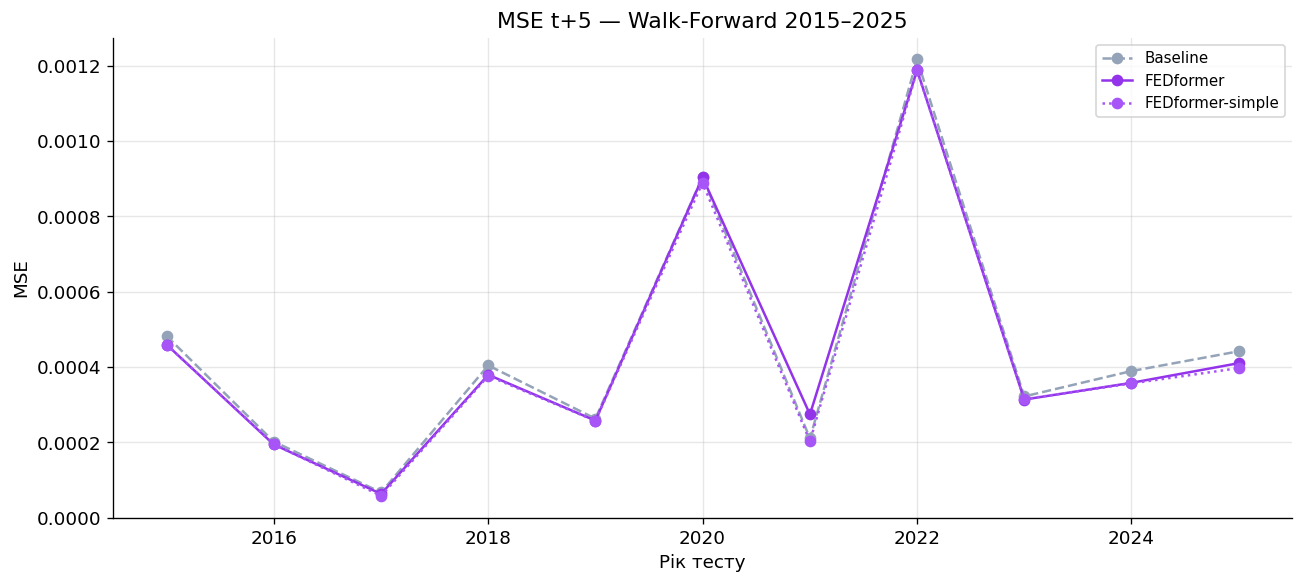

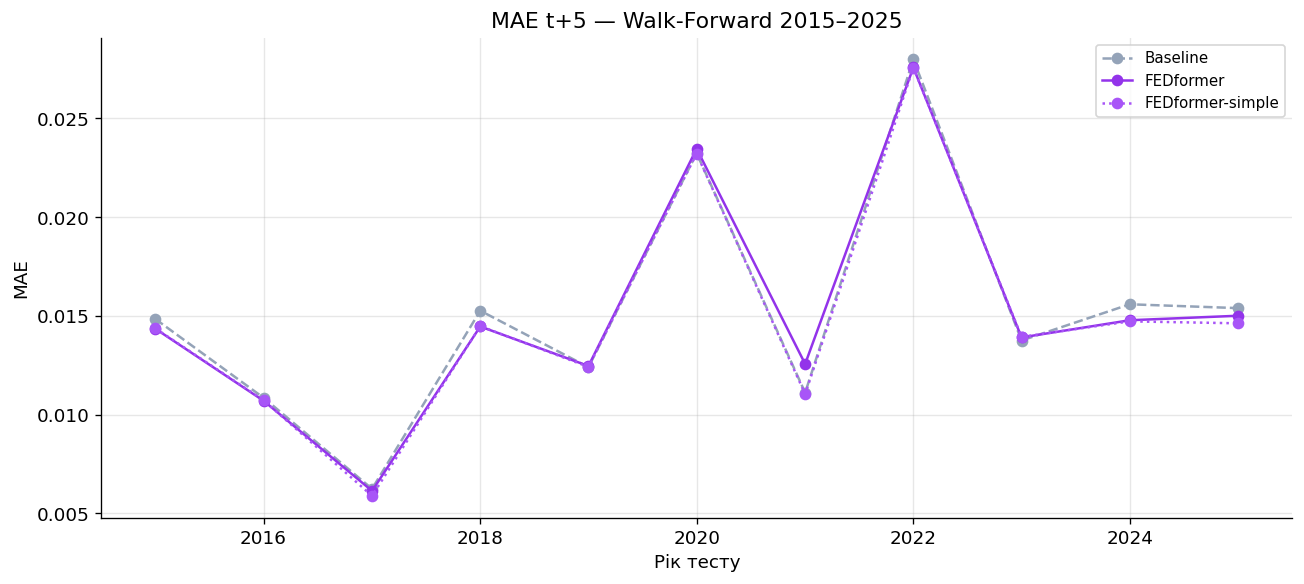

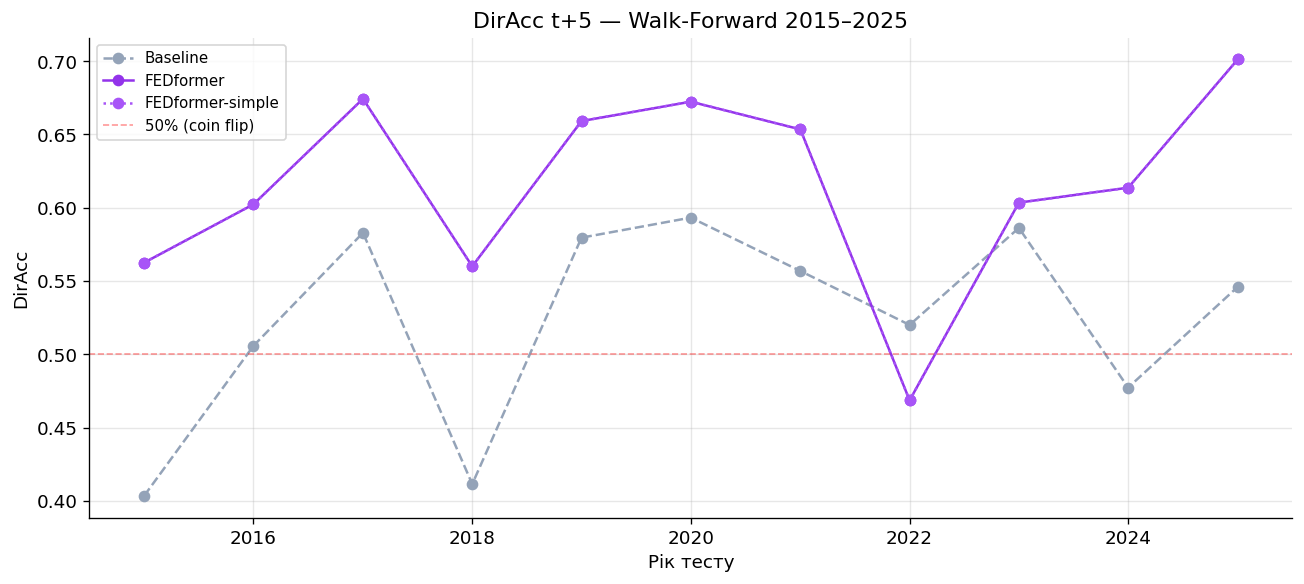

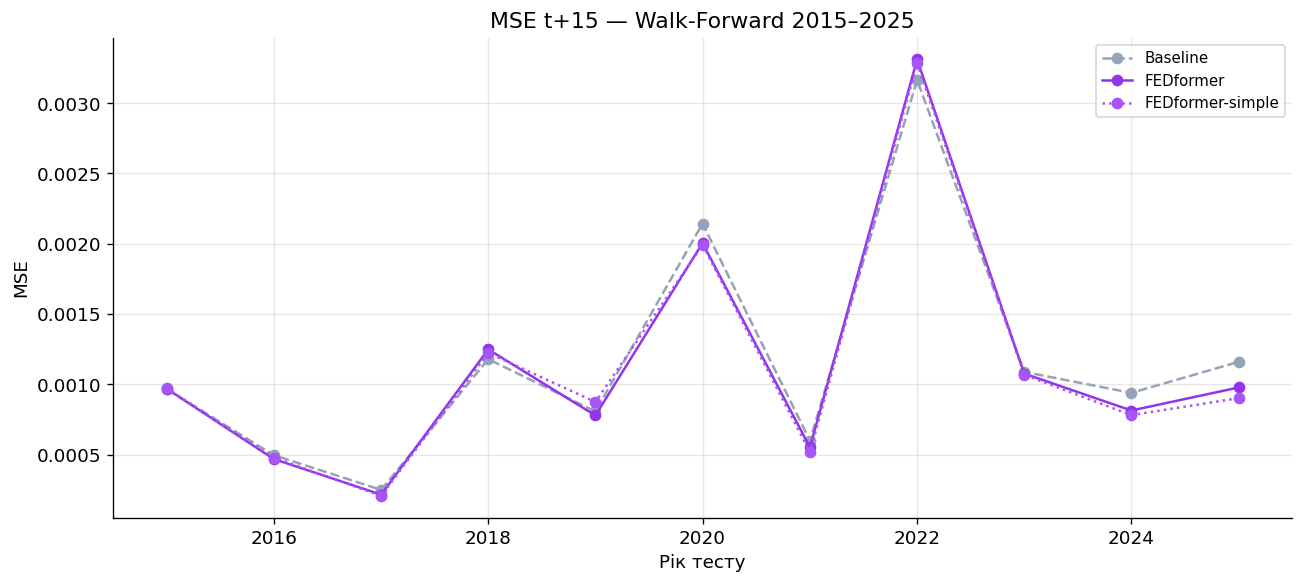

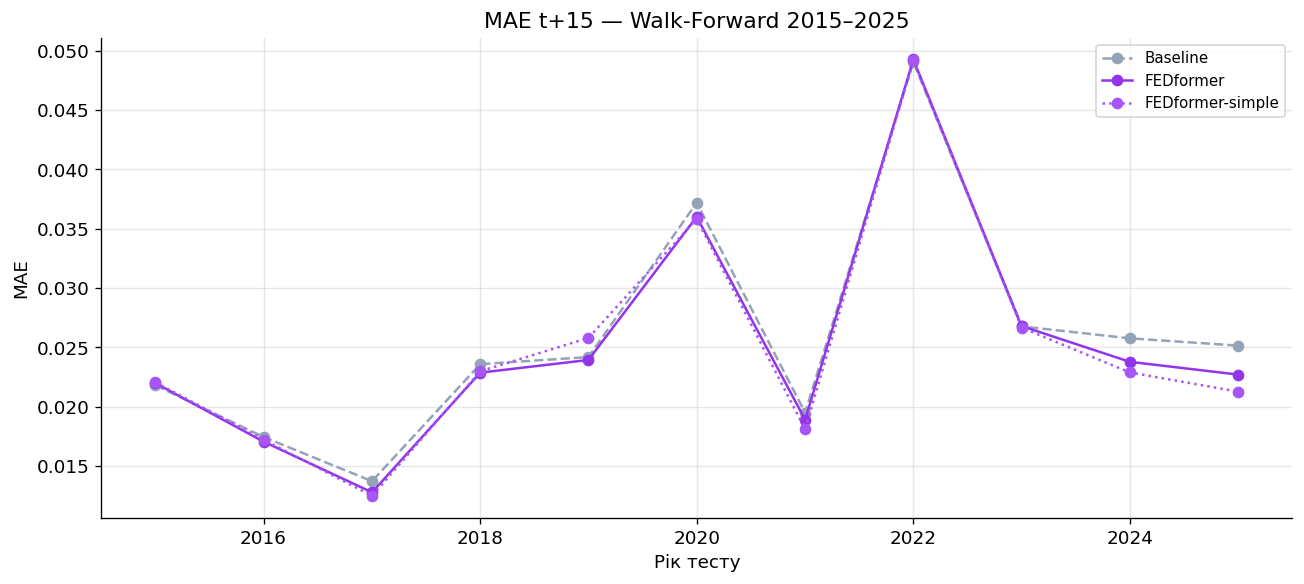

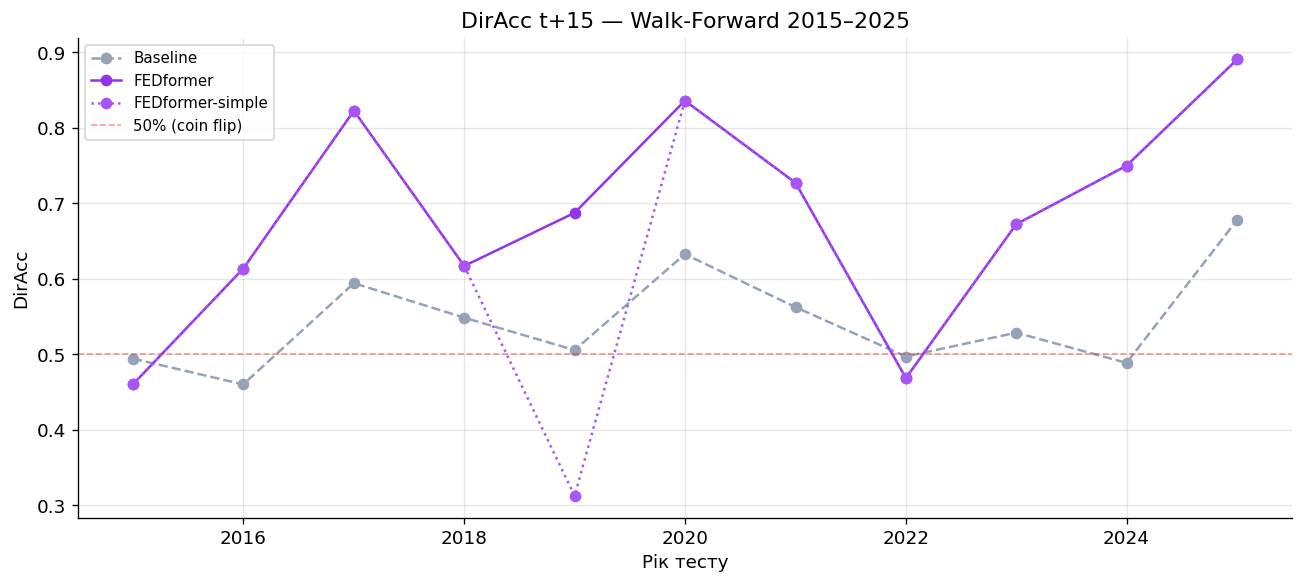

In [257]:
ALL_MODELS = {
    "Baseline":            os.path.join(RESULTS, "baseline",            "walk_forward.json"),
    #"LSTM":                os.path.join(RESULTS, "lstm",                "walk_forward.json"),
    #"LSTM-simple":         os.path.join(RESULTS, "lstm-simple",         "walk_forward.json"),
    #"Transformer":         os.path.join(RESULTS, "transformer",         "walk_forward.json"),
    #"Transformer-simple":  os.path.join(RESULTS, "transformer-simple",  "walk_forward.json"),
    #"Informer":            os.path.join(RESULTS, "informer",            "walk_forward.json"),
    #"Informer-simple":     os.path.join(RESULTS, "informer-simple",     "walk_forward.json"),
    "FEDformer":           os.path.join(RESULTS, "fedformer",           "walk_forward.json"),
    "FEDformer-simple":    os.path.join(RESULTS, "fedformer-simple",    "walk_forward.json"),
    "FEiT":         os.path.join(RESULTS, "feitransformer",        "walk_forward.json"),
    "FEiT-simple":  os.path.join(RESULTS, "feitransformer-simple", "walk_forward.json"),
}

print("=== Aggregate summary (mean over 11 folds) ===")
display(summary_table(ALL_MODELS))

plot_walk_forward(ALL_MODELS, metrics=("DirAcc",))

In [ ]:
def plot_params_vs_diracc(results_paths, horizons=None, styles=None, log_x=True,
                           annotate=True, figsize=(10, 6)):
    """Scatter: x=parameter count of best HP config, y=mean DirAcc across horizons.
    Reads `hparam_search.csv` (top row) for `n_params`, and `walk_forward.json`
    for aggregated DirAcc means. Higher y is better. 0.5 (coin flip) drawn as ref.
    """
    import matplotlib.pyplot as plt
    horizons = horizons or HORIZONS
    styles   = styles   or MODEL_STYLES

    points = []
    for name, wf_path in results_paths.items():
        if not os.path.exists(wf_path):
            print(f"[SKIP] {name} — {wf_path} not found")
            continue
        with open(wf_path) as f:
            agg = json.load(f)["aggregate"]
        try:
            diracc_overall = float(np.mean([agg[f"DirAcc_t{h}_mean"] for h in horizons]))
        except KeyError:
            print(f"[SKIP] {name} — DirAcc not in walk-forward aggregate")
            continue

        hp_csv = os.path.join(os.path.dirname(wf_path), "hparam_search.csv")
        n_params = None
        if os.path.exists(hp_csv):
            hp_df = pd.read_csv(hp_csv)
            if "n_params" in hp_df.columns and len(hp_df) > 0:
                # Top row already sorted by ranking metric (dir_acc or val_loss)
                n_params = int(hp_df.iloc[0]["n_params"])
        if n_params is None or n_params <= 0:
            print(f"[SKIP] {name} — no n_params (likely baseline)")
            continue
        points.append((name, n_params, diracc_overall))

    if not points:
        print("No models with both n_params and walk-forward results.")
        return

    fig, ax = plt.subplots(figsize=figsize)
    for name, n_params, dir_acc in points:
        _, color = styles.get(name, ("-", None))
        ax.scatter(n_params, dir_acc, color=color, s=90, zorder=3)
        if annotate:
            ax.annotate(name, (n_params, dir_acc), xytext=(6, 4),
                        textcoords="offset points", fontsize=9)
    ax.axhline(0.5, color="red", lw=1, ls="--", alpha=0.4, label="50% (coin flip)")
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel("Parameter count" + (" (log scale)" if log_x else ""))
    ax.set_ylabel(f"Overall DirAcc  (mean of t+{horizons})")
    ax.set_title("Розмір моделі vs точність напрямку (Walk-Forward)")
    ax.grid(True, alpha=0.3, zorder=1)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


plot_params_vs_diracc(ALL_MODELS)


---
## 7. Діагностика — приклад візуалізації

Запустіть `visualize_training()` для будь-якої моделі, щоб побачити криві train/val/test
за епохами та overfitting gap. Нижче — приклад для LSTM з найкращим конфігом
(на одному з пізніх walk-forward фолдів, де train-вікно найбільше).

train=5967  val=182  test=180
Параметрів: 545,539
  epoch   1  train=0.00115  val=0.00091  test=0.00098
  epoch   2  train=0.00059  val=0.00084  test=0.00089
  epoch   3  train=0.00055  val=0.00087  test=0.00088
  epoch   4  train=0.00052  val=0.00085  test=0.00086
  epoch   5  train=0.00051  val=0.00081  test=0.00079
  epoch   6  train=0.00051  val=0.00069  test=0.00072
  epoch   7  train=0.00050  val=0.00076  test=0.00073
  epoch   8  train=0.00049  val=0.00070  test=0.00072
  epoch   9  train=0.00047  val=0.00063  test=0.00066
  epoch  10  train=0.00045  val=0.00057  test=0.00062
  epoch  11  train=0.00044  val=0.00064  test=0.00071
  epoch  12  train=0.00043  val=0.00058  test=0.00058
  epoch  13  train=0.00044  val=0.00055  test=0.00059
  epoch  14  train=0.00042  val=0.00054  test=0.00057
  epoch  15  train=0.00039  val=0.00059  test=0.00062
  epoch  16  train=0.00038  val=0.00055  test=0.00060
  epoch  17  train=0.00038  val=0.00055  test=0.00056
  epoch  18  train=0.00036  val=

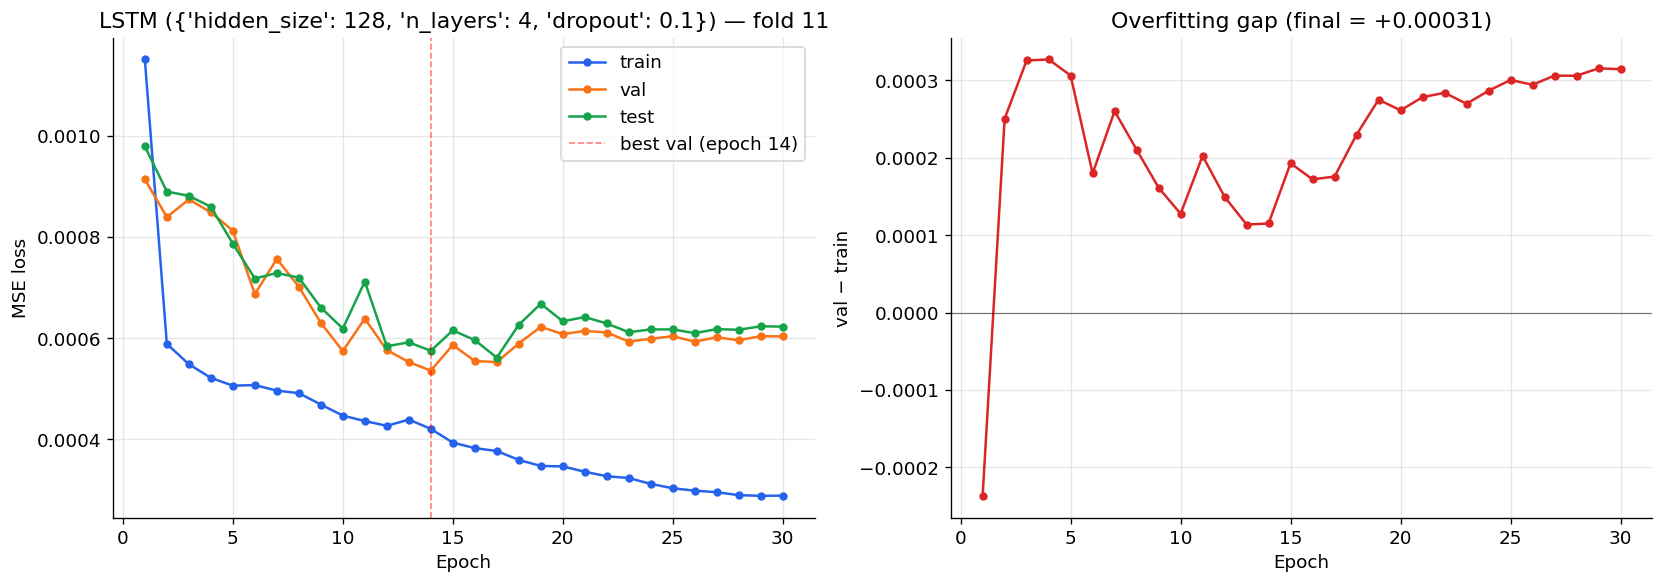

In [ ]:
# Беремо найкращий LSTM-конфіг і дивимося на криві навчання на останньому фолді
best = lstm_hp_df.iloc[0].to_dict()
model_params = {k: v for k, v in best.items()
                if k not in ("lr", "val_loss", "best_epoch", "n_params")}
for k in ("hidden_size", "n_layers"):
    if k in model_params:
        model_params[k] = int(model_params[k])

_ = visualize_training(
    model_factory = lstm_factory,
    model_params  = model_params,
    df_data       = df,
    lr            = float(best["lr"]),
    epochs        = 30,
    fold          = folds[-1],   # останній фолд: train 2000–2024, test 2025
    title         = f"LSTM ({model_params}) — fold 11",
)